In [1]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA
from new_lines import fitting_lines, a_ratio_dist, save_data, fit_auroral_new, save_data_auroral_MC

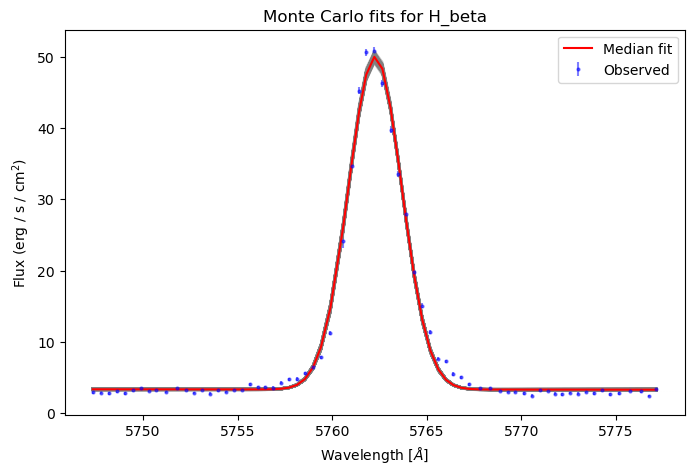

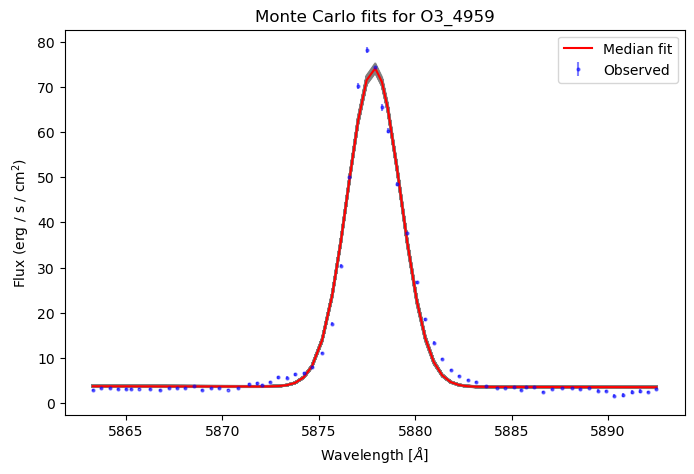

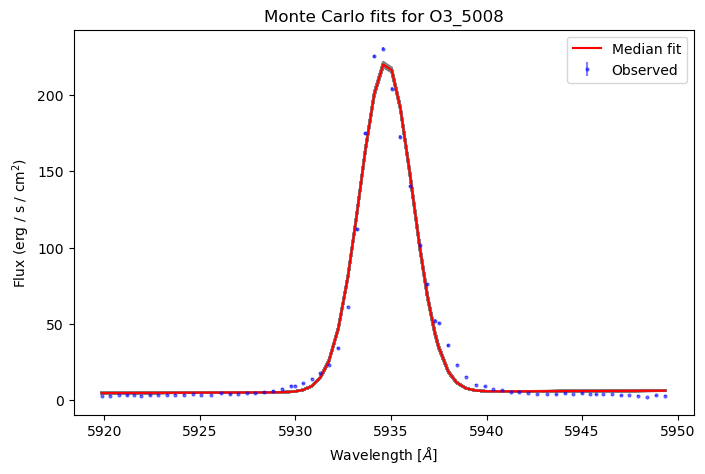

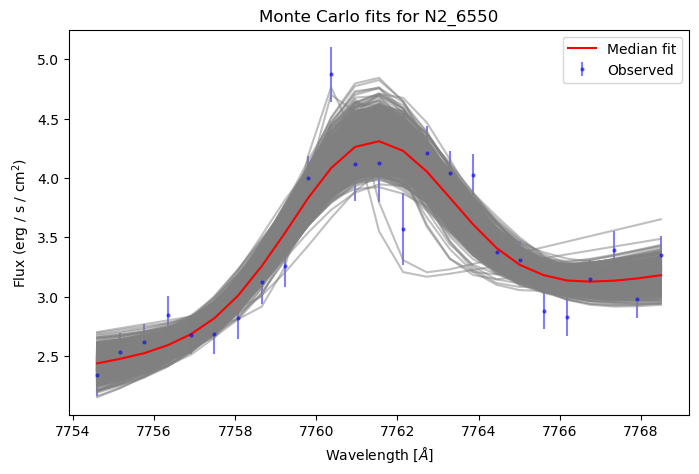

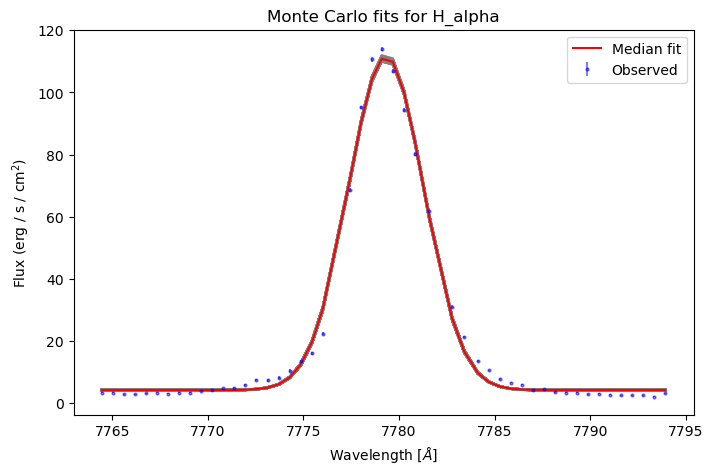

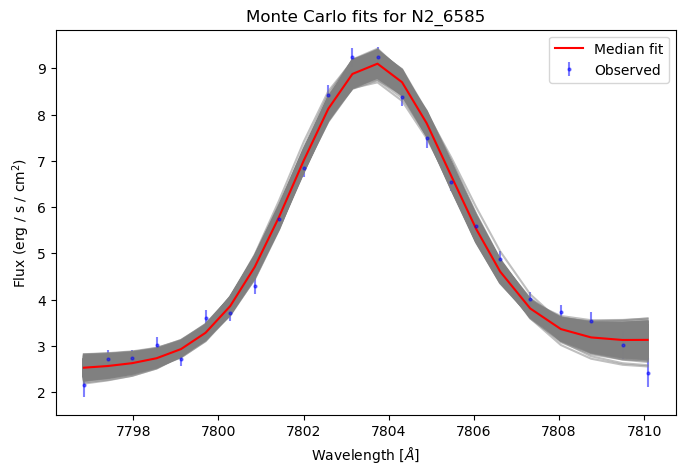

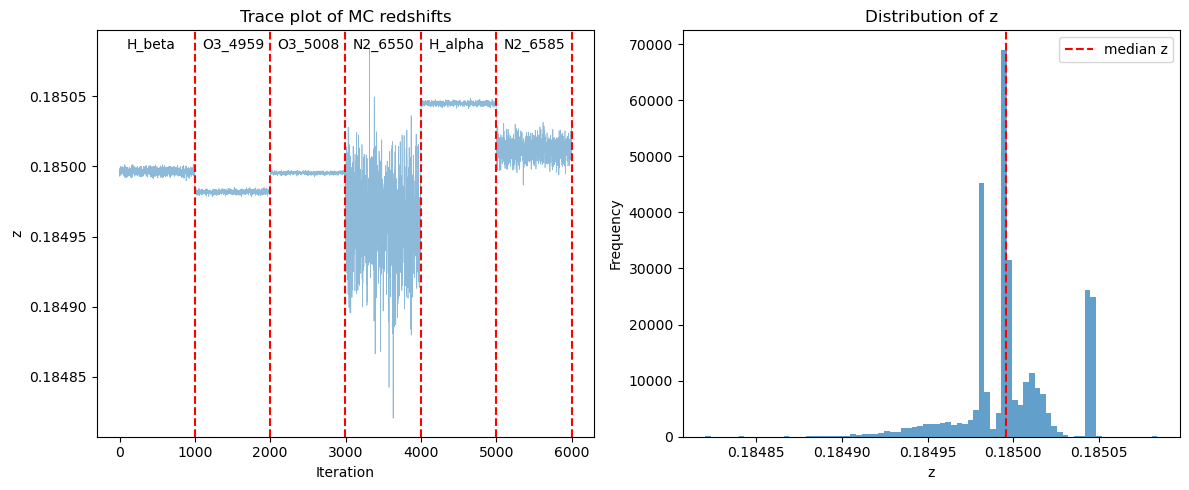

New redshift calculated for no_very_flats,z = 0.18499567683597595
Executed reset_redshift in 66.5885s


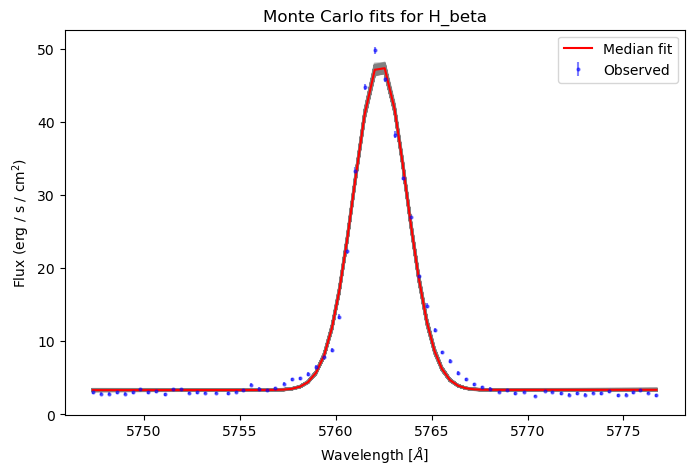

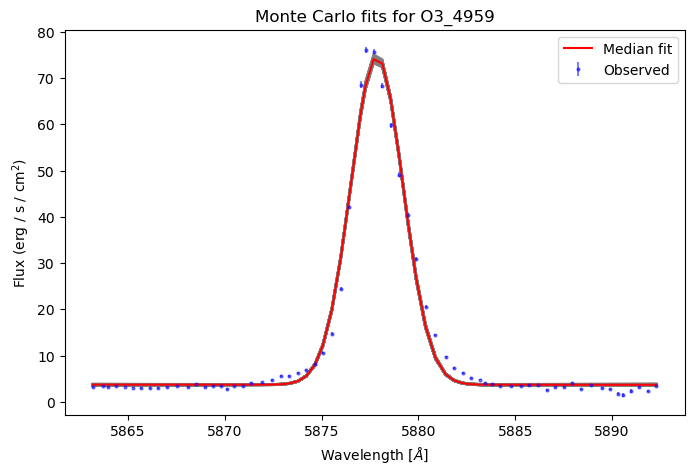

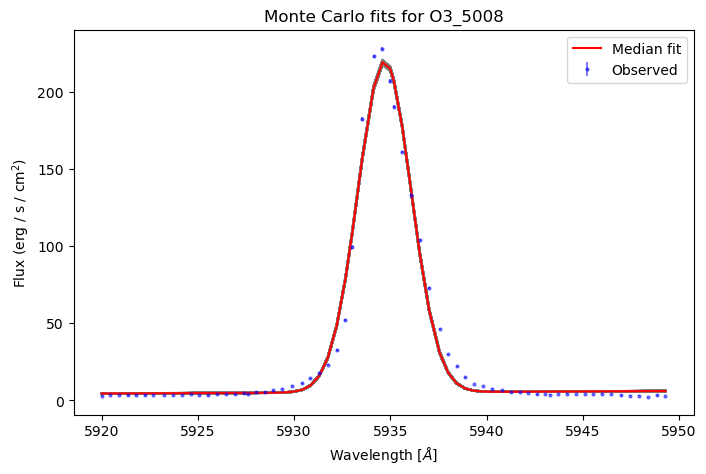

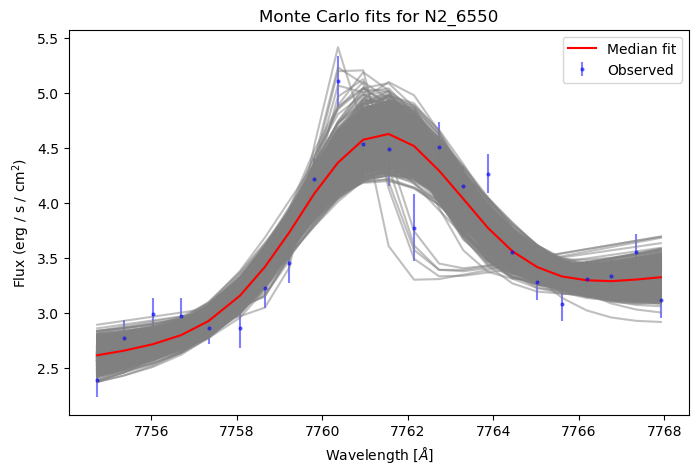

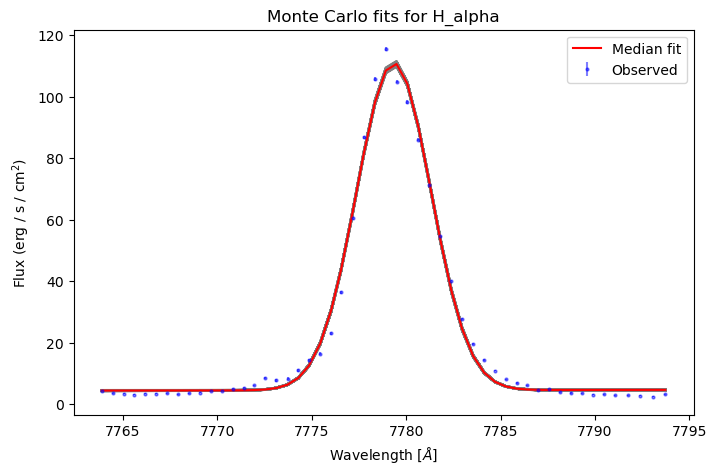

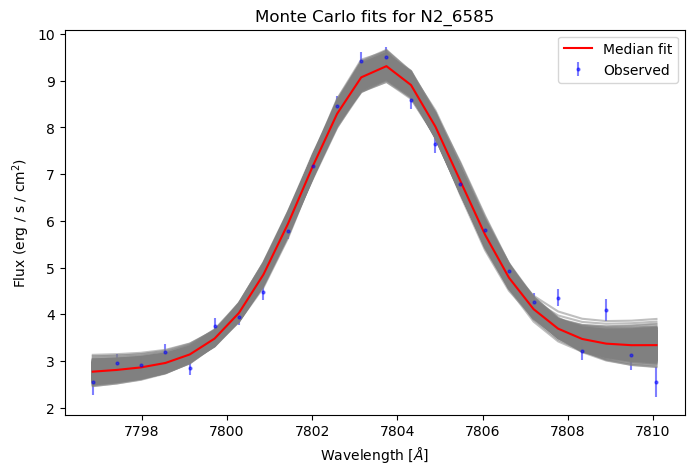

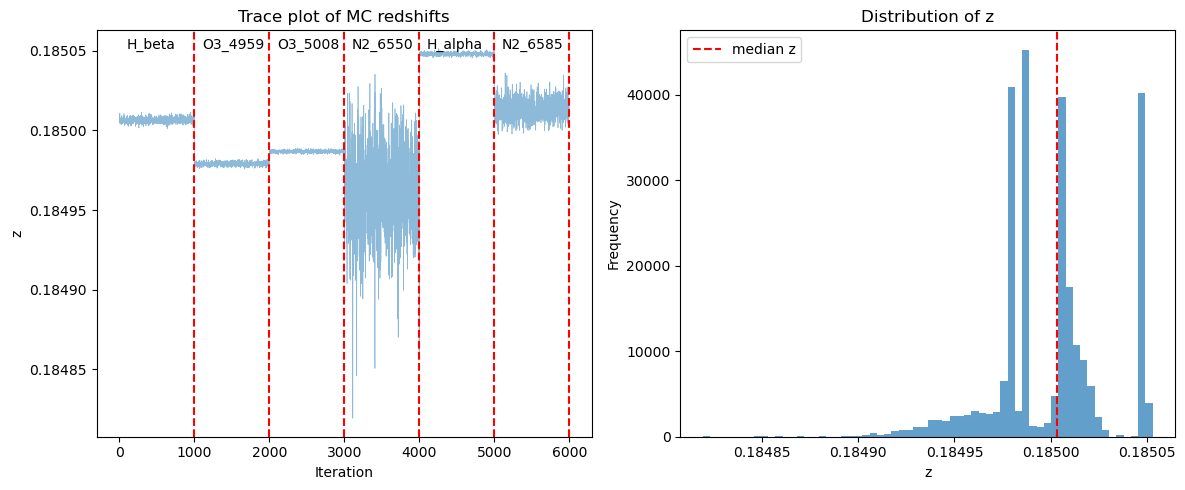

New redshift calculated for twilight,z = 0.18500303503243332
Executed reset_redshift in 66.8083s
New redshift for J2204+0058,z = 0.18499567683597595
Reading data for J2204
Using MW dust + Balmer abs corrected and continuum substracted data
Starting MC iteration
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done

,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J2204+0058,10.16,0.184998,H_14,11.975802,1.145999,0.562643,0.789678,11.501284,1.649303
1,J2204+0058,10.16,0.184998,O2_3725,116.867713,1.265260,104.281803,2.453130,12.503902,2.741536
2,J2204+0058,10.16,0.184998,O2_3727,241.193149,2.049454,95.590717,7.491614,146.029587,5.958524
3,J2204+0058,10.16,0.184998,H_13,2.710845,0.385315,2.700309,0.420791,0.000586,0.059646
4,J2204+0058,10.16,0.184998,H_12,2.404062,0.322608,1.401064,0.194426,0.972290,0.136466
5,J2204+0058,10.16,0.184998,H_11,2.574373,0.339627,1.526196,0.206573,1.058120,0.143251
6,J2204+0058,10.16,0.184998,H_10,5.060918,0.376050,2.973872,0.260668,2.047252,0.147505
7,J2204+0058,10.16,0.184998,H_9,8.690829,0.465018,5.135450,0.306080,3.532454,0.230872
8,J2204+0058,10.16,0.184998,Ne3_3868,56.082051,1.232469,33.272499,1.159639,22.990843,0.965852
9,J2204+0058,10.16,0.184998,He1_3898,27.142995,1.064638,15.992069,0.764398,11.088006,0.593038


In [1]:
from fit_lines import save_data
J2204_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/2-J2204/',
    'FILES': ['no_very_flats/J2204_NO_VERY_tellcorr.fits', 'twilight/J2204_TWILIGHT_tellcorr.fits'],
     'redshift': 0.185,
     'names':['J2204+0058'],
     'mass':10.16
}
save_data(J2204_SPECTRA, 100)

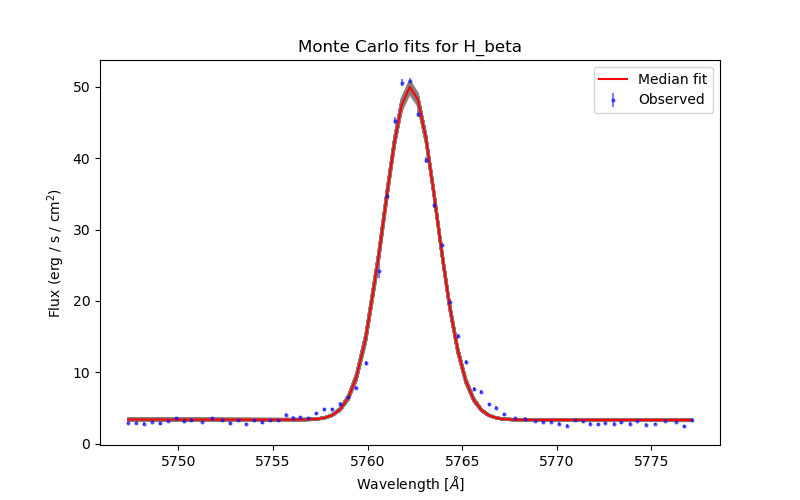

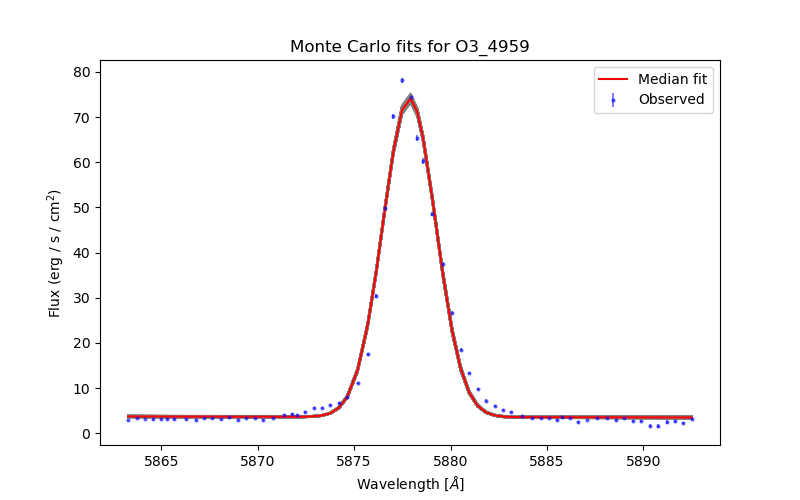

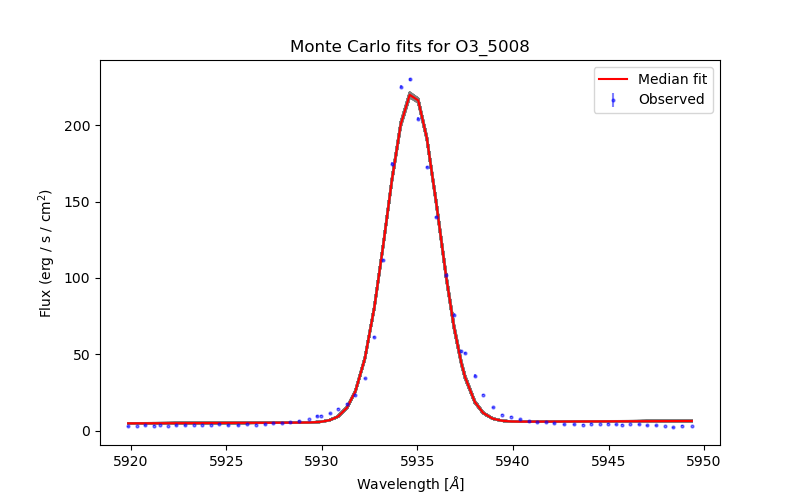

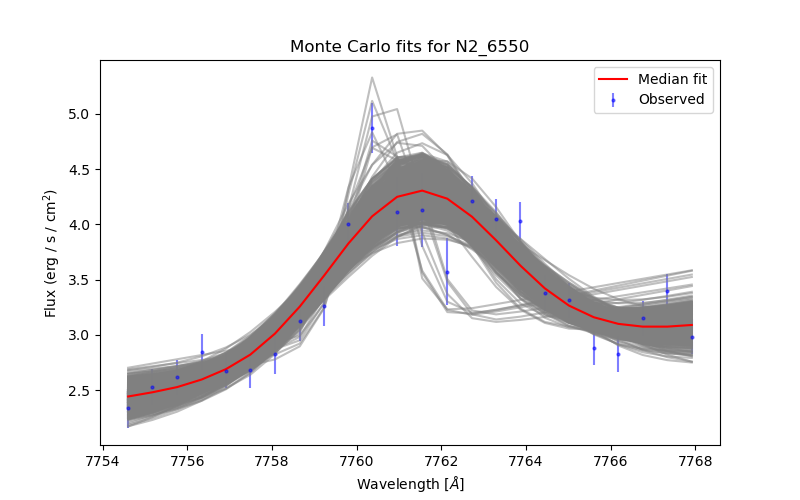

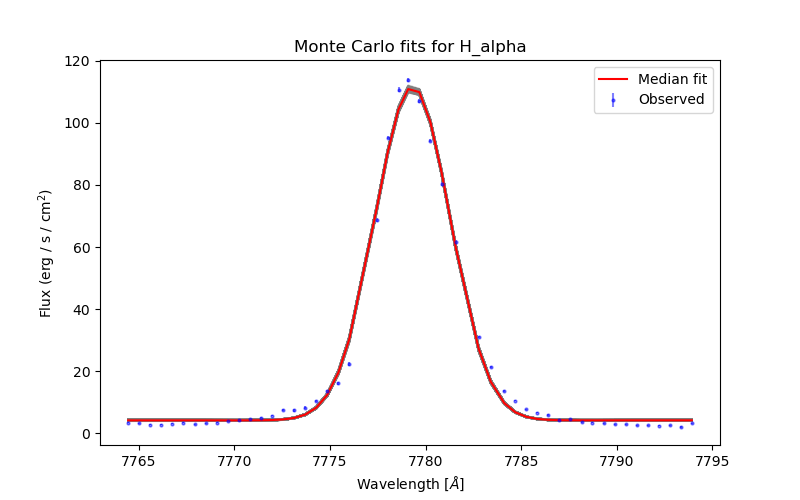

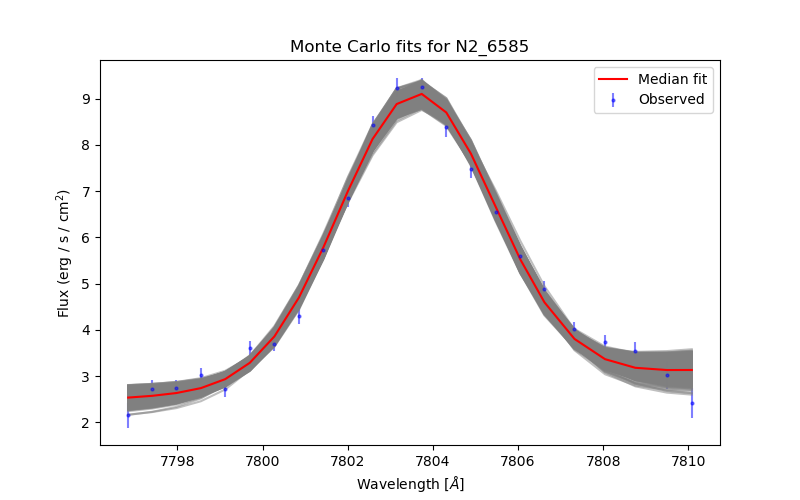

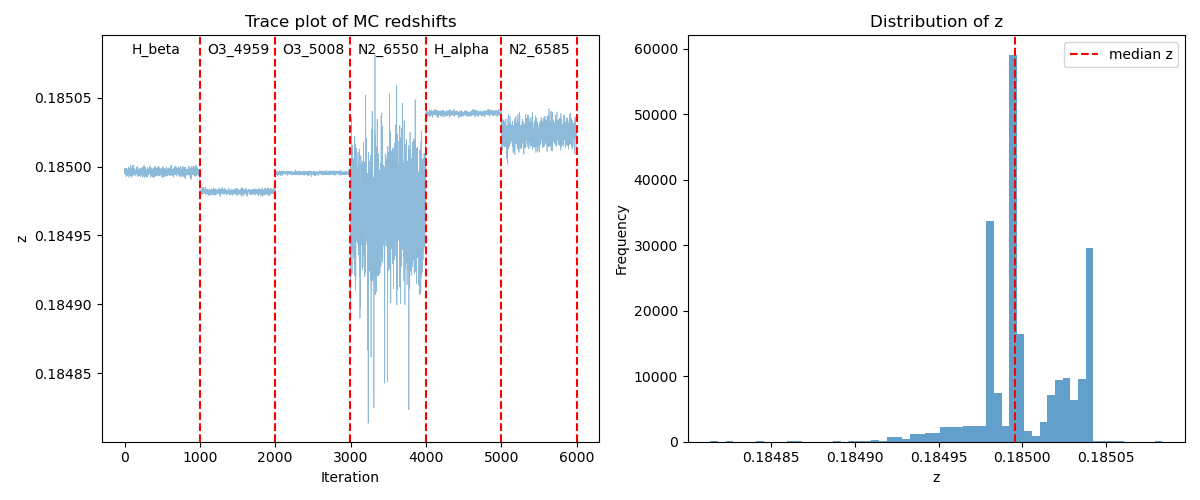

New redshift calculated for no_very_flats,z = 0.1849958142918715
Executed reset_redshift in 49.3395s


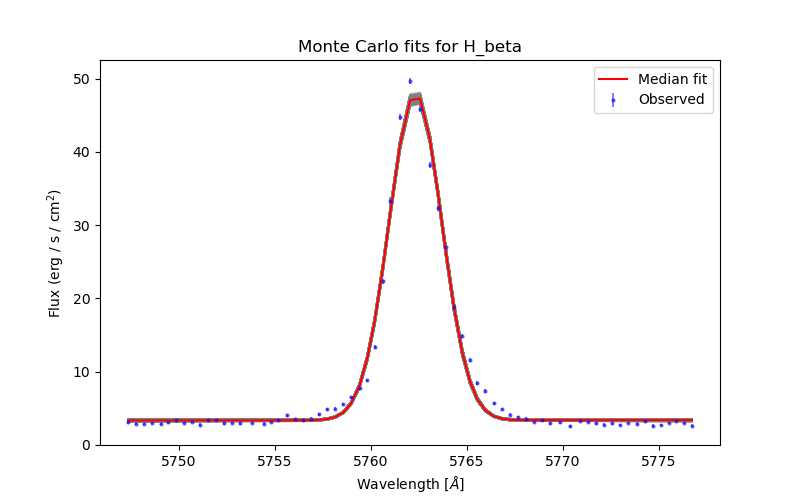

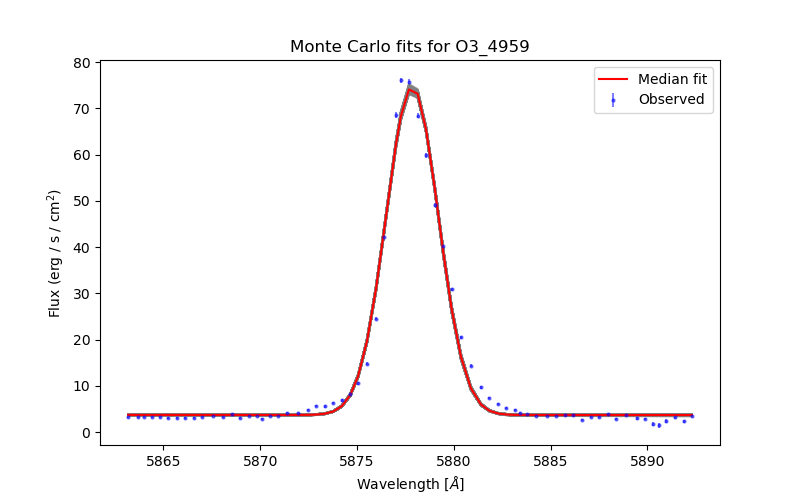

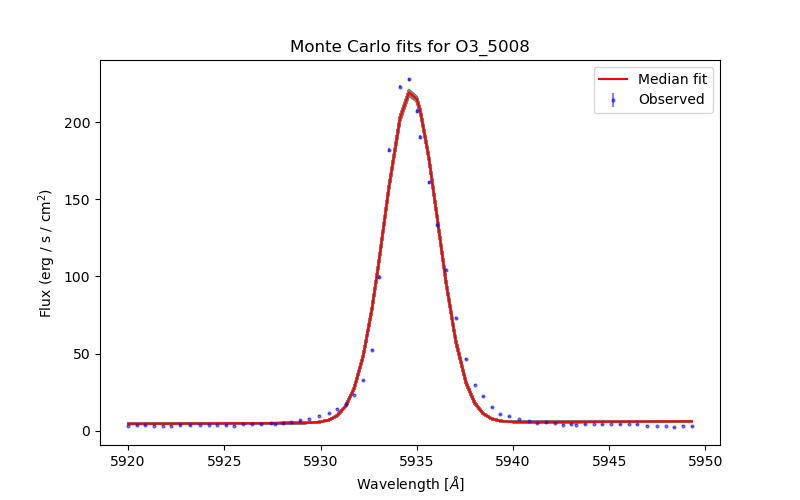

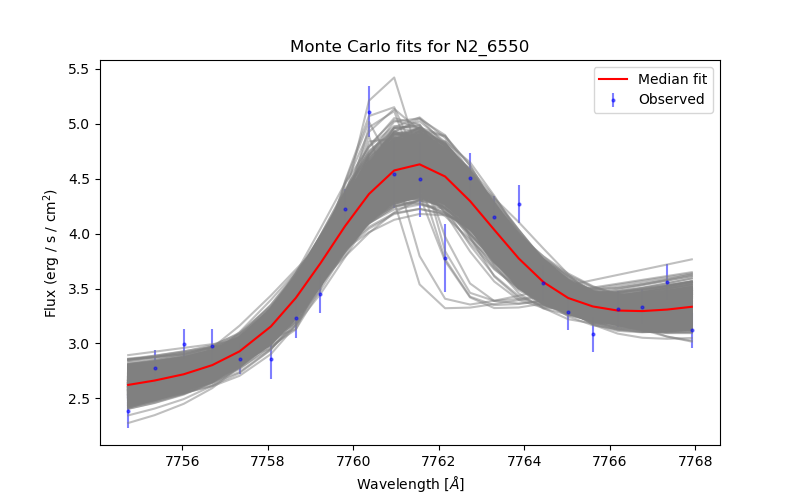

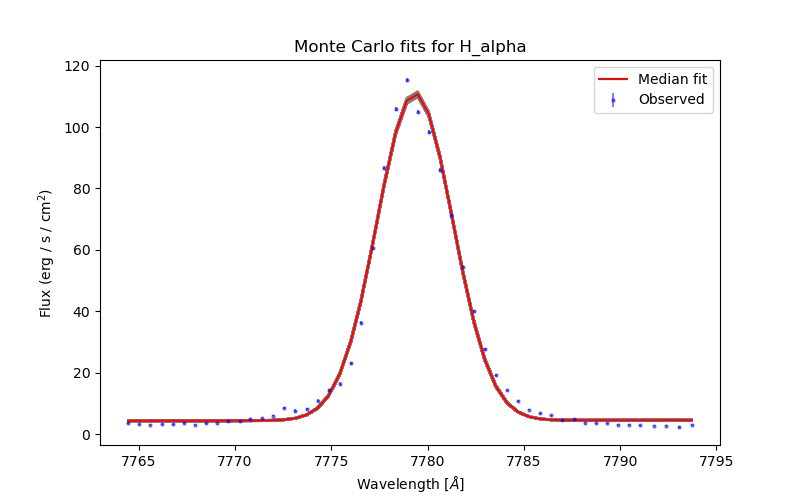

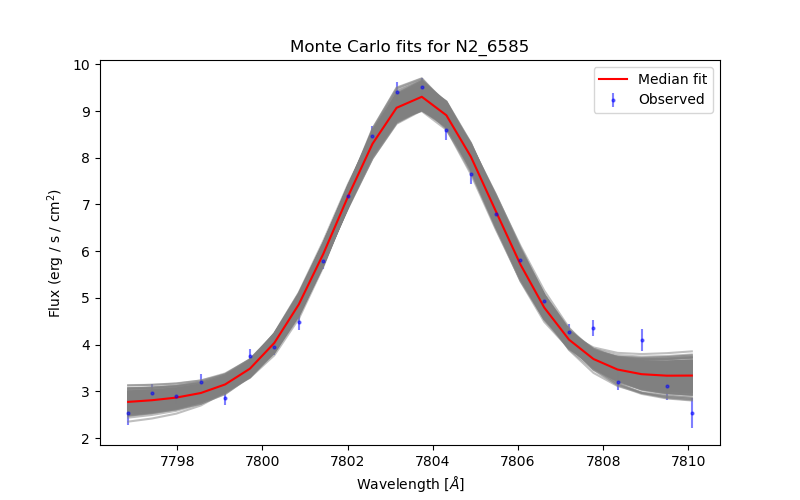

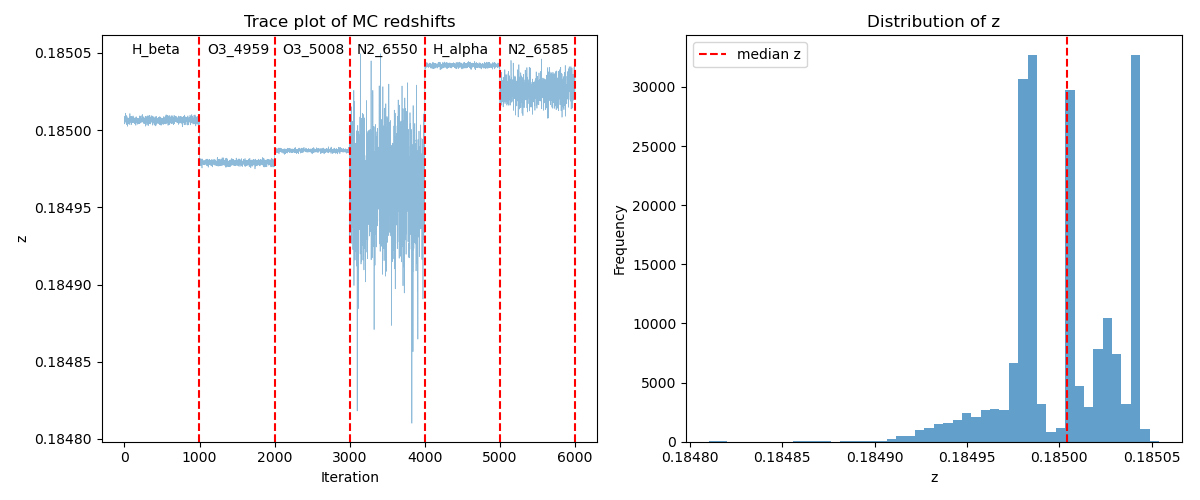

New redshift calculated for twilight,z = 0.1850041469044592
Executed reset_redshift in 50.9695s
New redshift for J2204+0058,z = 0.1849958142918715


In [2]:
J2204_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/2-J2204/',
    'FILES': ['no_very_flats/J2204_NO_VERY_tellcorr.fits', 'twilight/J2204_TWILIGHT_tellcorr.fits'],
     'redshift': 0.185,
     'names':['J2204+0058'],
     'mass':10.16
}
J2204 = SPECTRALDATA(J2204_SPECTRA)
Z = REDSHIFT(J2204)

Reading data for J2204
Using MW dust + Balmer abs corrected and continuum substracted data


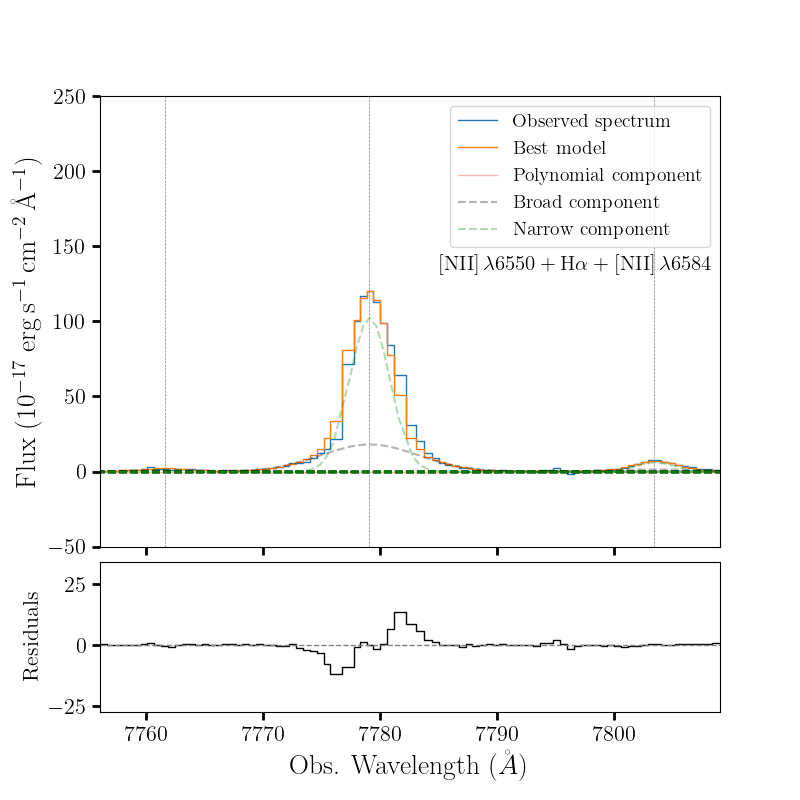

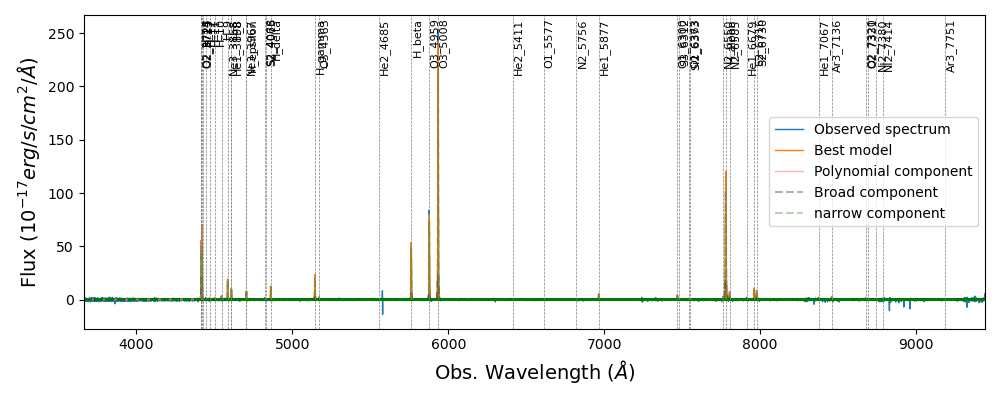

In [3]:
red = REDUC_LINES(J2204)
fit = red.fit_spectra(show_Plot=True)
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig2, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

comps = fit.eval_components(x=red.wave)

# --- Main spectrum ---
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid',
        label='Observed spectrum')

ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')

ax.plot(red.wave, comps['polynomial'], 'r-',
        label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]

for i, broad_line in enumerate(broad_key):
    ax.plot(red.wave, comps[broad_line] + comps['polynomial'],
            'k--',
            label='Broad component' if i == len(broad_key)-1 else None,
            alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    ax.plot(red.wave, comps[narrow_line] + comps['polynomial'],
            'g--',
            label='Narrow component' if i == len(narrow_key)-1 else None,
            alpha=0.3)


# --- Residuals ---
residuals = red.flux - fit.best_fit

ax_res.plot(red.wave, residuals,
            color='black',
            lw=1,
            drawstyle='steps-mid')

ax_res.axhline(0, color='grey', linestyle='--', lw=1)

ax_res.set_ylabel('Residuals', size=16)
ax_res.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
# ax_res.set_ylim(-40, 40)


# --- Emission line markers ---
for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1 + red.spectra.redshift)

    ax.axvline(obs_lam, linestyle='--',
               linewidth=0.5, color='grey')


ax.text(0.99, 0.65,
    r'$[\mathrm{NII}]\,\lambda6550 + \mathrm{H\alpha} +[\mathrm{NII}]\,\lambda6584$',
    transform=ax.transAxes,
    fontsize=15,
    color='k',
    ha='right',
    va='top'
)
# --- Formatting ---
ax.set_ylabel(r'Flux ($10^{-17}\ \mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$)', size=20)
obs_lam = red.spectra.linelist_dict['H_alpha'] * (1 + red.spectra.redshift)
ax.set_xlim(obs_lam-23, obs_lam+30)
ax.set_ylim(-50, 250)

ax.legend(fontsize=14, frameon=True, loc='upper right')
ax_res.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6, labelbottom=False
)


plt.show()

Reading data for J2204
Using MW dust + Balmer abs corrected and continuum substracted data


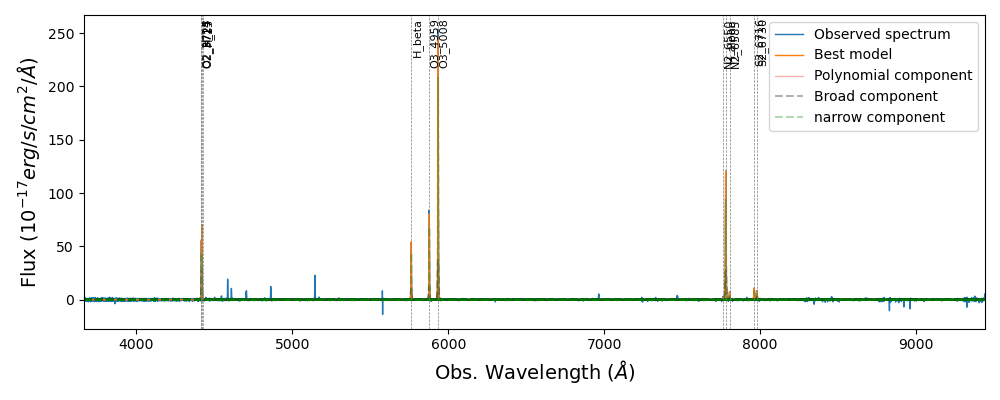

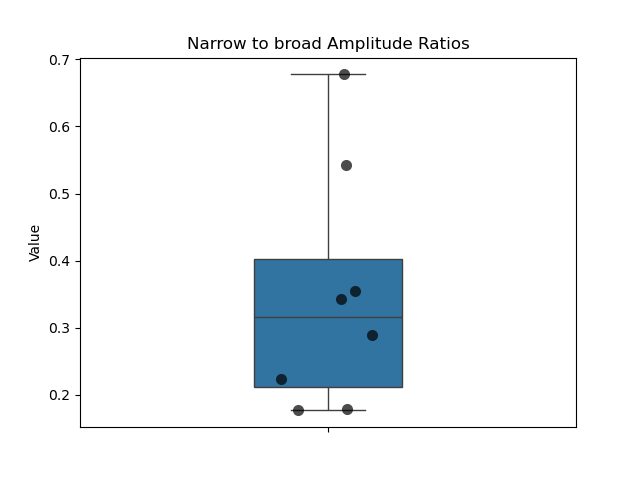

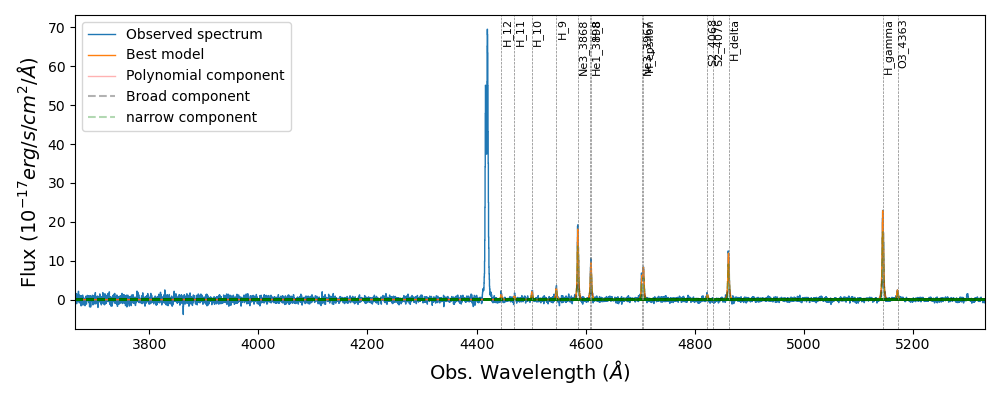

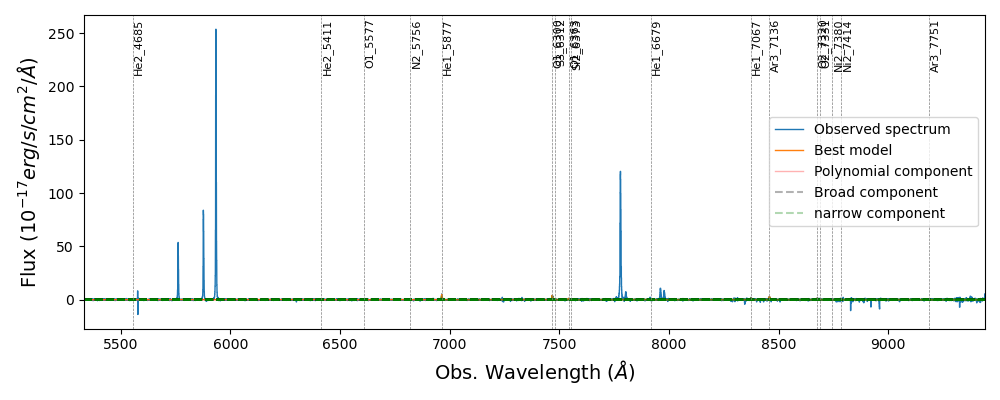

In [3]:
red = REDUC_LINES(J2204)
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

mask = (red.wave < 4500*(1+red.spectra.redshift))
wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

lines = red.spectra.linelist_dict
blue_lines = {k:v for k,v in lines.items() if v < 4500}
red_lines = {k:v for k,v in lines.items() if v >= 4500}


init = fitting_lines(red.wave, red.flux,
                    bright_dict,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)

out_blue = fitting_lines(wave1, flux1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

out_red = fitting_lines(wave2, flux2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [4]:
save_data(red, 100)

Starting MC iteration
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J2204/


,ID,mass,z_red,z_blue,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J2204+0058,10.16,0.184998,0.18502,H_14,8.527345e+00,0.907264,2.705171e+00,1.002885,5.715167,1.652664
1,J2204+0058,10.16,0.184998,0.18502,O2_3725,1.280242e+02,1.968821,1.075259e+02,3.611728,20.957286,3.805269
2,J2204+0058,10.16,0.184998,0.18502,O2_3727,2.283224e+02,1.613661,1.130373e+02,7.872170,115.252839,8.278096
3,J2204+0058,10.16,0.184998,0.18502,H_13,3.266958e+00,0.389252,3.250693e+00,0.388987,0.000247,0.054620
4,J2204+0058,10.16,0.184998,0.18502,H_12,3.423038e+00,0.315188,3.423038e+00,0.315188,0.000000,0.000000
5,J2204+0058,10.16,0.184998,0.18502,H_11,2.615245e+00,0.348334,2.615245e+00,0.348334,0.000000,0.000000
6,J2204+0058,10.16,0.184998,0.18502,H_10,5.242497e+00,0.368519,5.242497e+00,0.368519,0.000000,0.000000
7,J2204+0058,10.16,0.184998,0.18502,H_9,7.639599e+00,0.325185,7.639599e+00,0.325185,0.000000,0.000000
8,J2204+0058,10.16,0.184998,0.18502,Ne3_3868,4.806858e+01,0.684504,4.806858e+01,0.684504,0.000000,0.000000
9,J2204+0058,10.16,0.184998,0.18502,He1_3898,2.200380e+01,0.605273,2.200380e+01,0.605273,0.000000,0.000000


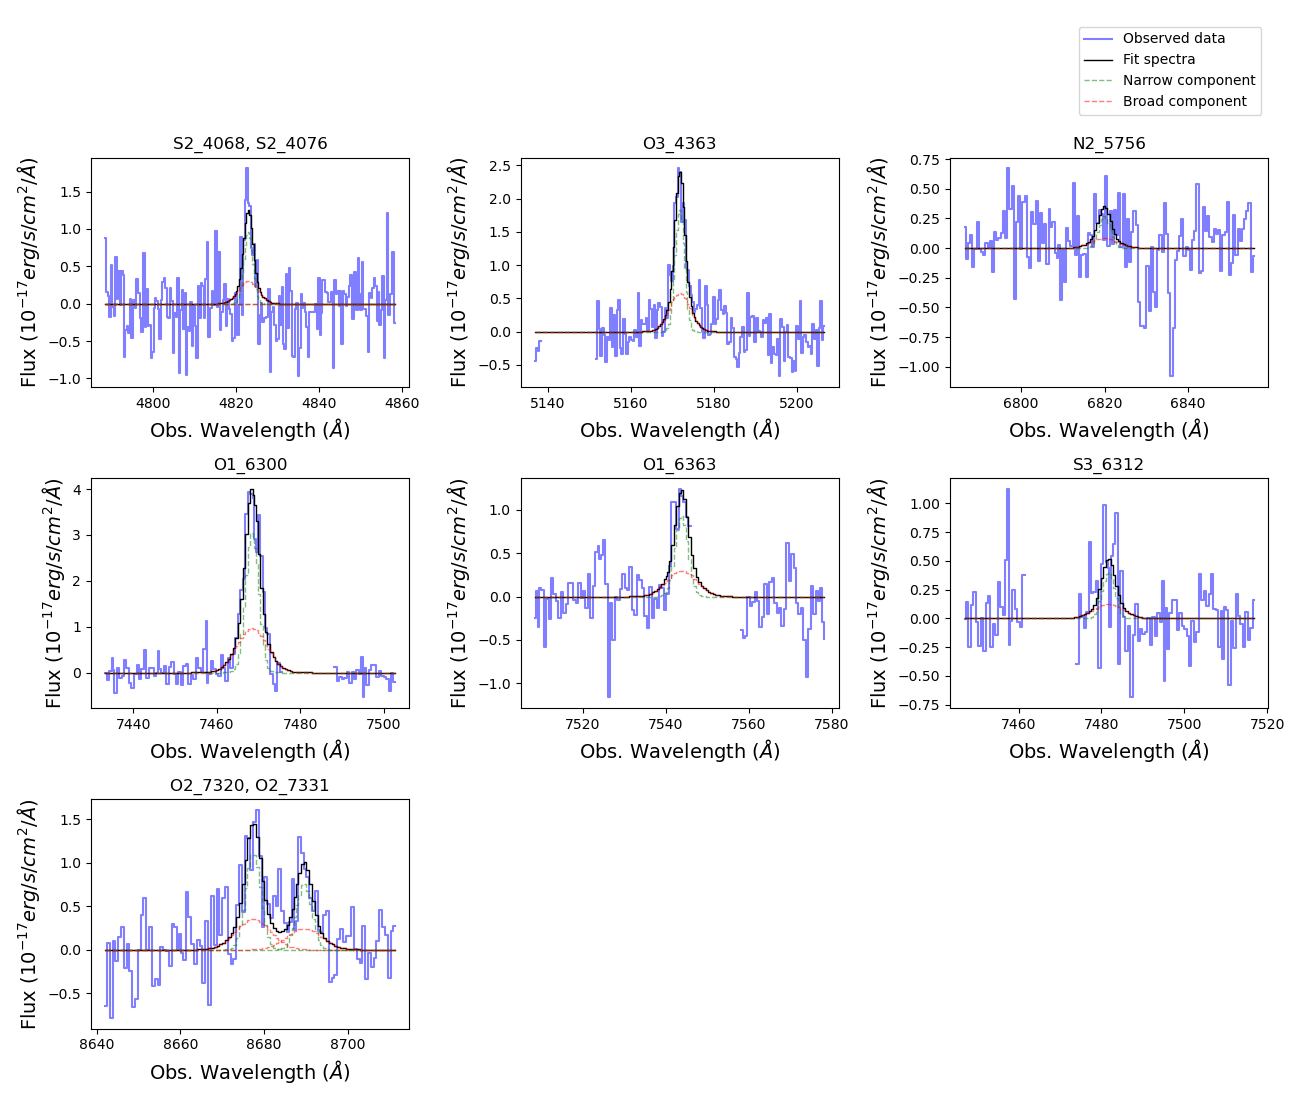

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/new_lines.py:542: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


In [5]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

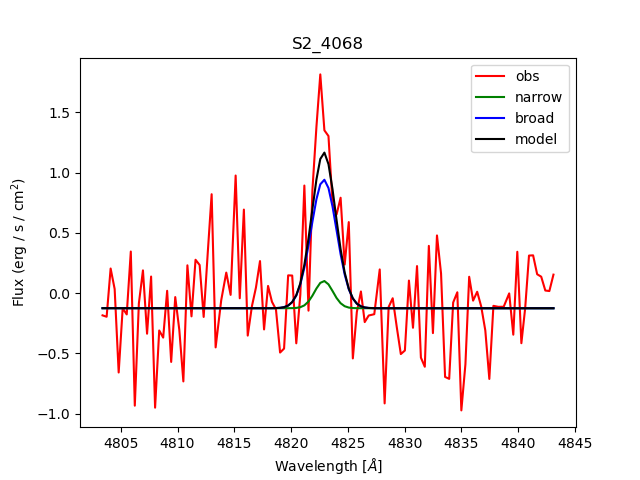

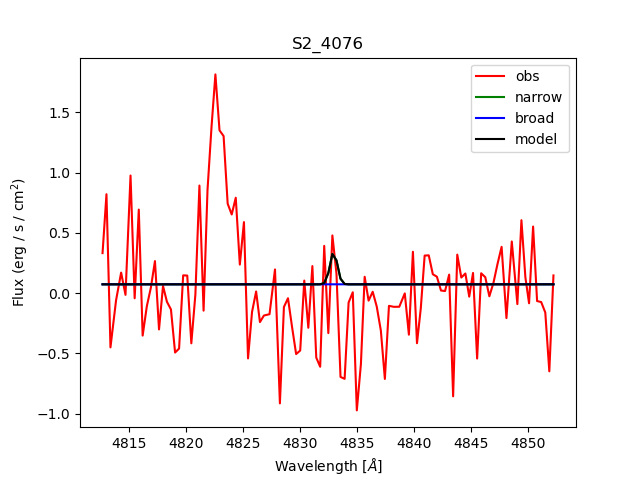

In [3]:
from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# get data
name= 'J2204'
save_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/{name}/cont_corr_{name}.csv'
dcorr = pd.read_csv(save_path)
wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

# stamp
labels = 'S2_4068', 'S2_4076'
class_ = J2204
df = pd.read_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')
for label in labels:
    wave_rest = class_.linelist_dict[label]
    wave_obs = wave_rest * (1 + class_.redshift)
    mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
    wave_stamp, flux_stamp = wave[mask], flux[mask]
    sigma_stamp = dcorr['sigma'][mask]

    # model
    narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
    broad_gaussian = GaussianModel(prefix=label+'_broad_')

    # Create a polynomial model for the continuum
    polydeg = 1
    polynomial = PolynomialModel(degree=polydeg)

    sum_of_gaussians = narrow_gaussian + broad_gaussian

    comp_mult = sum_of_gaussians + polynomial
    pars_mult = comp_mult.make_params()

    pars_mult.add(name='z', value=class_.redshift, vary=True)

    pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
    pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

    for param in ['center', 'amplitude', 'sigma']:
        narrow_key = f'{label}_narrow_{param}'
        if param == 'center':
            value = wave_rest
            vary = True
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 1
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
        pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                            vary=vary, expr=expr,
                                            min=0.0)


    for param in ['center', 'amplitude', 'sigma']:
        broad_key = f'{label}_broad_{param}'
        if param == 'center':
            value = wave_rest
            vary = False
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 0.3
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
        pars_mult[broad_key] = Parameter(name=broad_key,
                                            value=value, min=0.0,
                                            vary=vary, expr=expr)

    for i in range(polydeg+1):
        pars_mult[f'c{i:1.0f}'].set(value=0)

    comps = []
    for i in range(100):
        y_off = flux_stamp + np.random.randn(len(flux_stamp)) * sigma_stamp
        out_comp_mult = comp_mult.fit(y_off, pars_mult, x=wave_stamp,
                                        nan_policy='omit', max_nfev=1000)
        comps.append(out_comp_mult)

    # plot 1
    model = comps[0].eval_components(x=wave_stamp)
    plt.figure()
    plt.plot(wave_stamp, flux_stamp, color='red', label='obs')
    plt.plot(wave_stamp, model[f'{label}_narrow_'] + model['polynomial'], color='green', label='narrow')
    plt.plot(wave_stamp, model[f'{label}_broad_'] + model['polynomial'], color='blue', label='broad')
    plt.plot(wave_stamp, comps[0].best_fit, color='black', label='model')
    plt.title(label)
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(r'Flux (erg / s / cm$^{2}$)')
    plt.title(label)
    plt.legend()
    plt.show()

    # Saving
    sum_narr = []
    sum_bro = []
    sum = []
    for comp in comps:
        sum_narr.append(comp.params[f'{label}_narrow_amplitude'].value)
        sum_bro.append(comp.params[f'{label}_broad_amplitude'].value)
        sum.append(comp.params[f'{label}_narrow_amplitude'].value + comp.params[f'{label}_broad_amplitude'].value)
    median_narr = np.median(sum_narr)
    std_narr = np.std(sum_narr)

    median_bro = np.median(sum_bro)
    std_bro = np.std(sum_bro)

    median = np.median(sum)
    std = np.std(sum)

    new_row ={
        'ID':df['ID'][0],
        'mass': df['mass'][0],
        'z':df['z'][0],
        'name':label,
        'flux':median,
        'fluxerr':std,
        'narrow_flux':median_narr,
        'narrow_fluxerr':std_narr,
        'broad_flux':median_bro,
        'broad_fluxerr':std_bro
    }
    df.loc[len(df)] = new_row
df.to_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')

Performing dust correction for J2204
Extinction correction done! Using total curve.


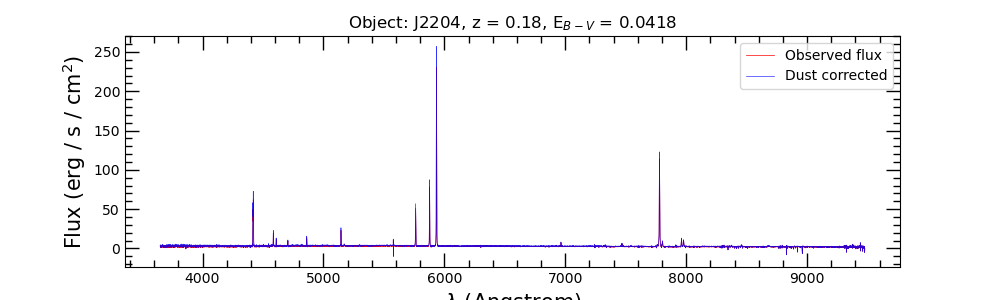

Saved figure at: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J2204/dcorr_J2204.pdf
Using uncorrected data


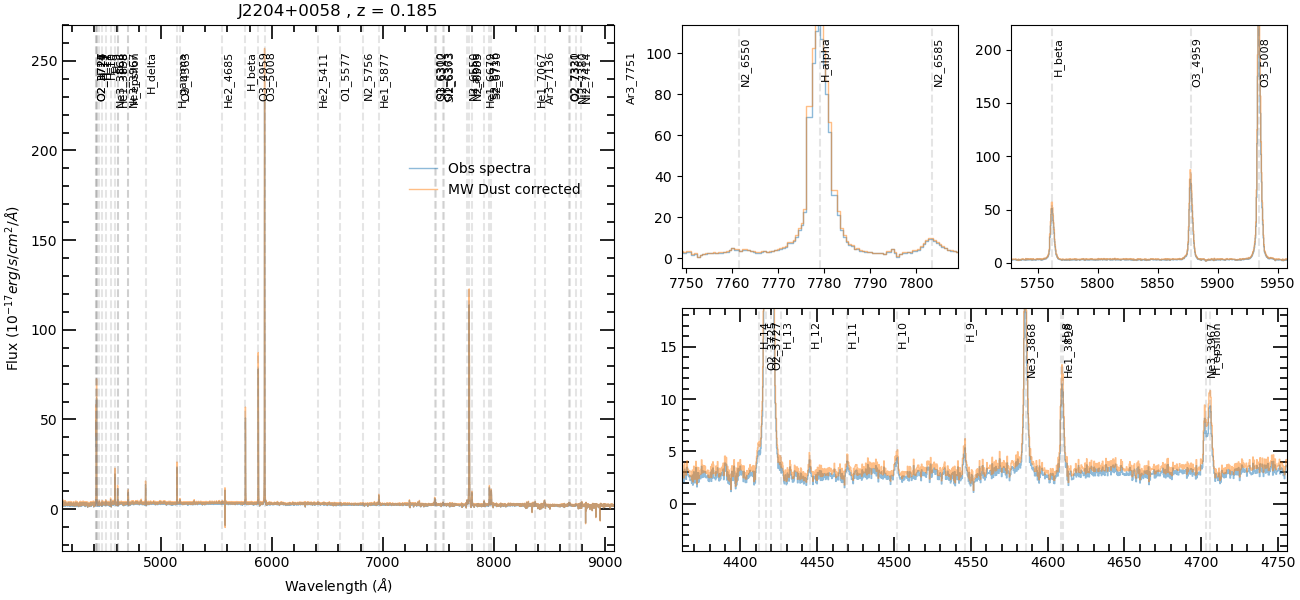

Saved MW dust corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J2204/dcorr_J2204.csv
Executed MW_dust_corr in 1.1961s


In [3]:
MW_DUST_CORR(J2204, plot=True)

In [9]:
import os

import astropy.constants as const
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from GaussianFitting import fitSpectrum
from lmfit import Parameter
from lmfit.models import GaussianModel, PolynomialModel

main_DIR = "/Users/javieratoro/Desktop/thesis/"
proj_DIR = f"{main_DIR}proyecto 2024-2/"
code_DIR = f"{proj_DIR}codes"

class BALMER_ABS:
    """
    Class to estimate and correct the Balmer absoprtion on a galaxy spectra.


    Receives the SPECTRALDATA class and a boolean for plotting the correction;
    and save the balmer-corrected spectra using a build-in model.

    """

    def __init__(self, spectra, showplot=False, verbose=False):
        self.spectra = spectra
        self.gal_id = self.spectra.names[0][:5]
        # Set Balmer lines names
        self.balmer_lines = ['H_beta', 'H_gamma', 'H_delta',
                             'H_epsilon', 'H_8', 'H_9', 'H_10', 'H_11', 'H_12',
                             'H_13', 'H_14']

        # Read MW dust corrected data if it exist
        self.read_data()
        self.bal_abs_corr(plot=showplot)

    def bal_abs_corr(self, plot=False):
        print(f'Performing Balmer absorption correction for {self.gal_id}')

        # Get sigma from first model
        sigmas = self.first_sigma_est()

        # Get stamps masked and unmasked
        self.get_stamp(sigmas)

        # Get model for each emission line
        self.model_absorption(self.stamps)

        # Apply balmer absorption correction
        new_flux = self.correct_data(self.stamps, self.comps, plot=plot)

        # Save data
        self.save_corrected_data(new_flux)

        print("Balmer absorption correction done!")

    def read_data(self):
        """
        Reads MW duct corrected data if it exist, otherwise reads the
        uncorrected data.
        """
        print(f'Reading data for {self.gal_id}')
        file_path = f'{proj_DIR}dust/{self.gal_id}/dcorr_{self.gal_id}.csv'
        if os.path.exists(file_path):
            print("Using MW dust corrected data")
            dcorr = pd.read_csv(file_path)
            arrays = dcorr.to_numpy().T  # Transpose to get column-wise array
            self.wave, self.flux, self.sigma = arrays

        else:
            print("Using uncorrected data")
            self.wave, self.flux, self.sigma, _ = self.spectra.datas[0]

    def first_sigma_est(self, plot=False):
        """
        Get the velocity dispersion (sigma) of the narrow and/or broad
        Gaussian components from the spectral fitting.

        Add plot=True to visualize the spectral fitting model
        """
        if self.spectra.model1IT is None:
            fit = fitSpectrum(self.wave, self.flux, self.sigma,
                              linelist=self.spectra.linelist_dict,
                              z_init=self.spectra.redshift,
                              weights=1/self.sigma**2,
                              showPlot=plot,
                              broad=True, nfev=1000)
            self.spectra.model1IT = fit
        else:
            fit = self.spectra.model1IT

        sigma_narrow = fit.params['sigma_v_narrow']
        sigma_broad = fit.params['sigma_v_broad']

        return [sigma_narrow, sigma_broad]

    def get_stamp(self, sigmas):
        """
        Create stamps for every emission line 25*sigma from center,
        masking the emission lines for future modelling.
        """
        bright_lines = ['O2_3725', 'O2_3727', 'H_alpha', 'H_beta', 'H_gamma',
                        'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585', 'S2_6716',
                        'S2_6730']
        self.masked_flux = self.flux.copy()
        self.stamps = []

        [sigma_narr, sigma_broad] = sigmas

        def get_sigma(label):
            if label in bright_lines:
                sigma = (center / const.c.to('km/s').value) * sigma_broad.value
            else:
                sigma = (center / const.c.to('km/s').value) * sigma_narr.value
            return sigma

        # Mask every emission line 3 sigma from center
        cte = (1 + self.spectra.redshift)
        for label in self.spectra.linelist_dict:
            center = self.spectra.linelist_dict[label] * cte
            sigma = get_sigma(label)

            size = 4.0
            mask_below = (self.wave > center - size*sigma)
            mask_up = (self.wave < center + size*sigma)
            mask_line = mask_below & mask_up

            # Every line to nan
            self.masked_flux[mask_line] = np.nan

        # Create the stamp 25 sigma from center
        for label in self.balmer_lines:
            center = self.spectra.linelist_dict[label] * cte
            sigma = get_sigma(label)
            sep = 20 if label in self.balmer_lines[6:] else 50

            mask_below = (self.wave > center - sep*sigma)
            mask_up = (self.wave < center + sep*sigma)
            mask_stamp = mask_below & mask_up

            masked_stamp = self.masked_flux[mask_stamp]
            stamp = self.flux[mask_stamp]
            masked_wave = self.wave[mask_stamp]

            self.stamps.append([masked_wave, stamp, masked_stamp])
        return self.stamps

    def model_absorption(self, stamps):
        """
        Create the model for the absoption with a negative gaussian
        and a 1-degree polynomial
        """
        self.comps = []
        for label, stamp_ in zip(self.balmer_lines, stamps):
            masked_wave, _, masked_stamp = stamp_

            # Gaussian model for balmer abs
            gaussian = GaussianModel(prefix=label+'_')

            # Create a polynomial model for the continuum
            polydeg = 1
            polynomial = PolynomialModel(degree=polydeg)

            comp_mult = gaussian + polynomial
            pars_mult = comp_mult.make_params()

            pars_mult.add(name='z', value=self.spectra.redshift,
                          vary=False)

            pars_mult.add(name='sigma_v', value=300)

            # Loop through emission lines to define parameters
            # for narrow and broad

            lam = self.spectra.linelist_dict[label]
            center = lam * (1 + self.spectra.redshift)
            min_am = -100 if label in self.balmer_lines[:7] else -40
            if label == 'H_gamma':
                min_am = -1

            for param in ['center', 'amplitude', 'sigma']:
                narrow_key = f'{label}_{param}'
                if param == 'center':
                    value = lam
                    vary_ = False
                    min_ = None
                    max_ = None
                    expr = f'{lam:6.2f}*(1+z)'
                elif param == 'amplitude':
                    value = -30
                    vary_ = True
                    min_ = min_am
                    max_ = 0
                    expr = None
                elif param == 'sigma':
                    value = (450 * center / const.c.to('km/s')).value
                    vary_ = True
                    min_ = (200 * center / const.c.to('km/s')).value
                    max_ = (700 * center / const.c.to('km/s')).value
                    expr = f'(sigma_v/3e5)*{label}_center'
                pars_mult[narrow_key] = Parameter(name=narrow_key,
                                                  value=value,
                                                  vary=vary_, expr=expr,
                                                  min=min_, max=max_)
            for i in range(polydeg+1):
                pars_mult[f'c{i:1.0f}'].set(value=0)

            out_comp_mult = comp_mult.fit(masked_stamp, pars_mult,
                                          x=masked_wave,
                                          nan_policy='omit',
                                          max_nfev=1000)

            self.comps.append(out_comp_mult)
        return self.comps

    def correct_data(self, stamps, comps, plot=False):
        """
        Compute the balmer correction and plot the correction if indicated
        """
        new_flux = self.flux.copy()
        wave = self.wave.copy()
        for stamp_, comp, label in zip(stamps, comps, self.balmer_lines):
            mask_wave, stamp, masked_stamp = stamp_
            mask = (wave >= np.min(mask_wave)) & (wave <= np.max(mask_wave))
            model_flux = comp.eval_components(x=mask_wave)
            balmer_abs = model_flux[f'{label}_']
            new_flux[mask] -= balmer_abs

            if plot:
                _, axs = plt.subplots(1, 3, figsize=(14, 4))
                axs[0].plot(mask_wave, stamp, lw=1, drawstyle='steps-mid',
                            alpha=0.5)
                axs[0].plot(mask_wave,
                            model_flux[f'{label}_'] + model_flux['polynomial'],
                            lw=1, drawstyle='steps-mid',
                            label='Balmer abs model')
                axs[0].set_title(f'{label} balmer absorption')
                axs[0].set_xlabel(r'Wavelength $\AA$')
                axs[0].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
                axs[0].set_ylim(np.mean(model_flux['polynomial'])-10,
                                np.mean(model_flux['polynomial'])+10)
                axs[0].legend()
                axs[1].plot(mask_wave, stamp, lw=1, drawstyle='steps-mid',
                            alpha=0.5)
                axs[1].plot(mask_wave, masked_stamp,
                            lw=1, drawstyle='steps-mid',
                            label='Masked spectra')
                axs[1].set_xlabel(r'Wavelength $\AA$')
                axs[1].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
                axs[1].set_ylim(np.mean(model_flux['polynomial'])-10,
                                np.mean(model_flux['polynomial'])+10)
                axs[1].legend()
                axs[2].plot(wave[mask], stamp, alpha=0.5,
                            lw=1, drawstyle='steps-mid',
                            label='Uncorrected flux')
                axs[2].plot(wave[mask], new_flux[mask], alpha=0.5,
                            lw=1, drawstyle='steps-mid',
                            label='Corrected flux')
                axs[2].plot(wave[mask], model_flux['polynomial'],
                            alpha=0.3, label='Continuum')
                axs[2].set_xlabel(r'Wavelength $\AA$')
                axs[2].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
                axs[2].set_ylim(np.mean(model_flux['polynomial'])-10,
                                np.mean(model_flux['polynomial'])+10)
                axs[2].legend()
                save_dir = f'{proj_DIR}bal_abs/{self.gal_id}'
                os.makedirs(save_dir, exist_ok=True)
                path = f'{save_dir}/{label}_balabs.pdf'
                plt.savefig(path,
                            format='pdf')
                plt.show()
        return new_flux

    def EW(self):
        res = pd.DataFrame(columns=['ID', 'z', 'name', 'sigma', 'EW'])
        for comp, label, stamp_ in zip(self.comps, self.balmer_lines,
                                       self.stamps):
            mask_wave, _, _ = stamp_
            A = comp.params[f'{label}_amplitude']
            cont = np.mean(comp.eval_components(x=mask_wave)['polynomial'])
            EW = A/cont
            center = comp.params[f'{label}_center']
            sigma = comp.params[f'{label}_sigma']*const.c.to('km/s')/center

            row = {'ID': self.spectra.names[0],
                   'z': self.spectra.redshift,
                   'name': label,
                   'sigma': sigma.value,
                   'EW': EW
                   }
            res.loc[len(res)] = row

        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].scatter(res['EW'][1:].index + 4, -res['EW'][1:])
        axs[0].set_xlabel('Balmer order')
        axs[0].set_ylabel('EW')
        axs[1].set_ylabel('sigma [km/s]')
        axs[1].set_xlabel('Balmer order')
        axs[1].scatter(res['sigma'][1:].index + 4, res['sigma'][1:])
        plt.show()

        save_dir = f'{proj_DIR}bal_abs'
        save_path = f'{save_dir}/{self.gal_id}_EW.csv'
        os.makedirs(save_dir, exist_ok=True)
        res.to_csv(save_path, index=False)
        return res

    def save_corrected_data(self, new_flux):
        """
        Saves the corrected data to a CSV file,
        creating the directory if needed.
        """
        # Define the directory and file path
        save_dir = f'{proj_DIR}bal_abs'
        save_path = f'{save_dir}/bcorr_{self.gal_id}.csv'

        # Create the directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)

        # Create and save DataFrame
        df = pd.DataFrame({'wave': self.wave, 'flux': new_flux,
                           'sigma': self.sigma})
        df.to_csv(save_path, index=False)

        IMAGES(self.spectra, [(self.wave, new_flux)], ['Balmer corrected'],
               f'{proj_DIR}bal_abs', f'bcorr_{self.gal_id}')

        print(f'Saved Balmer Absorption corrected data to: {save_path}')


Reading data for J2204
Using MW dust corrected data
Performing Balmer absorption correction for J2204


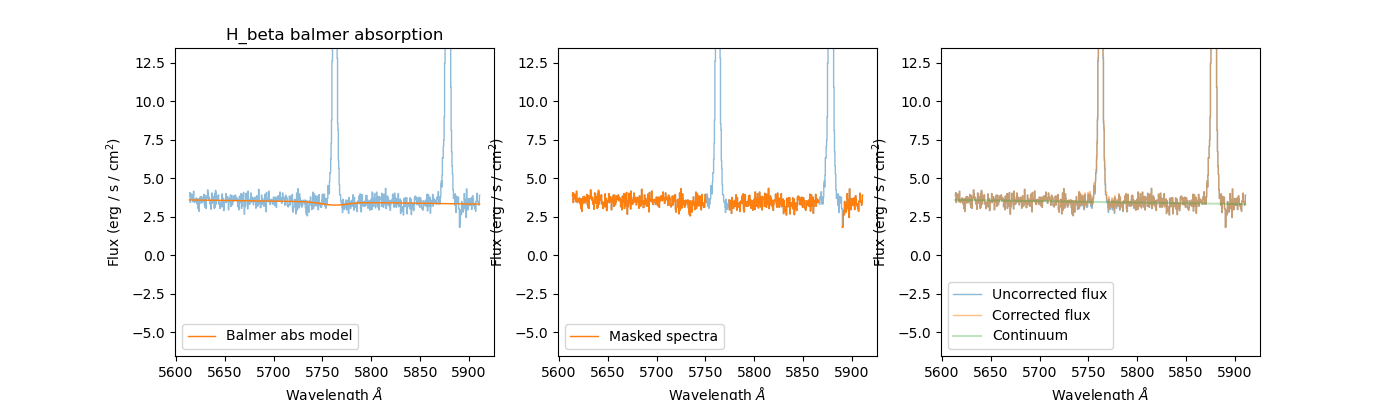

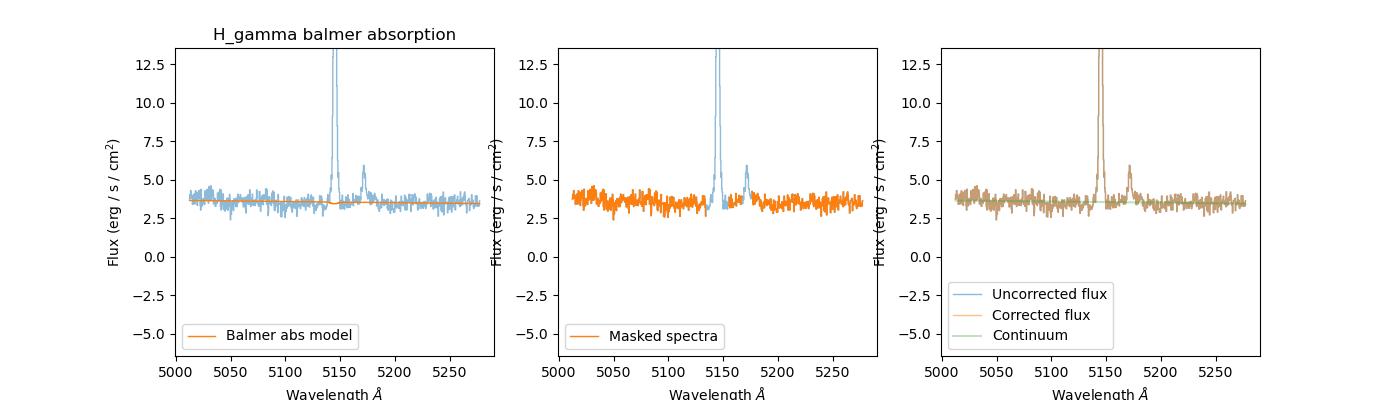

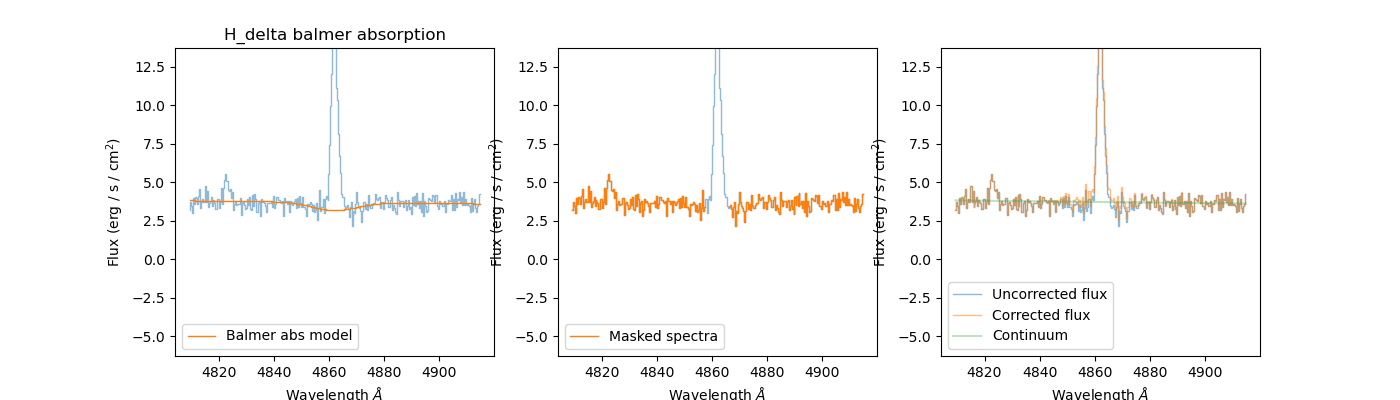

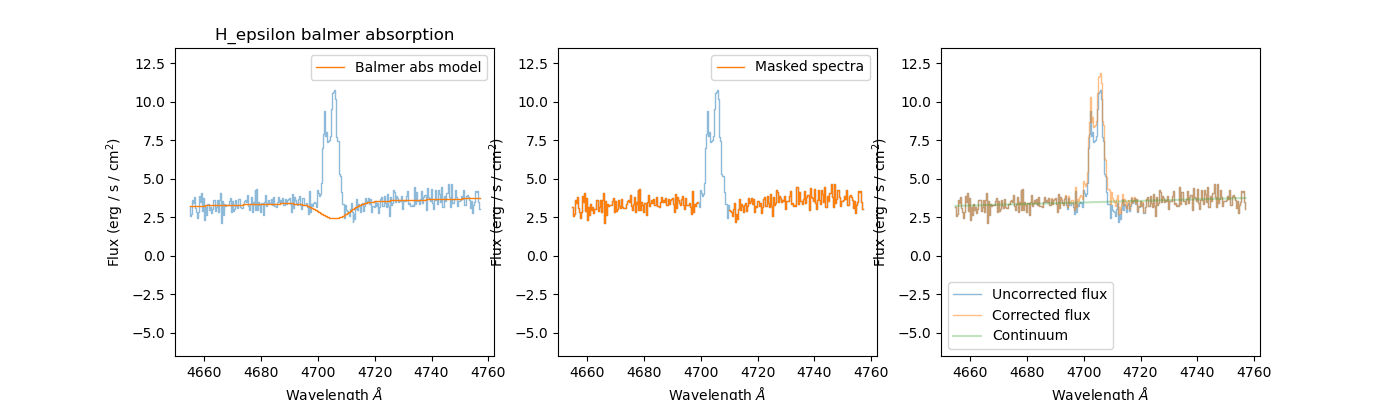

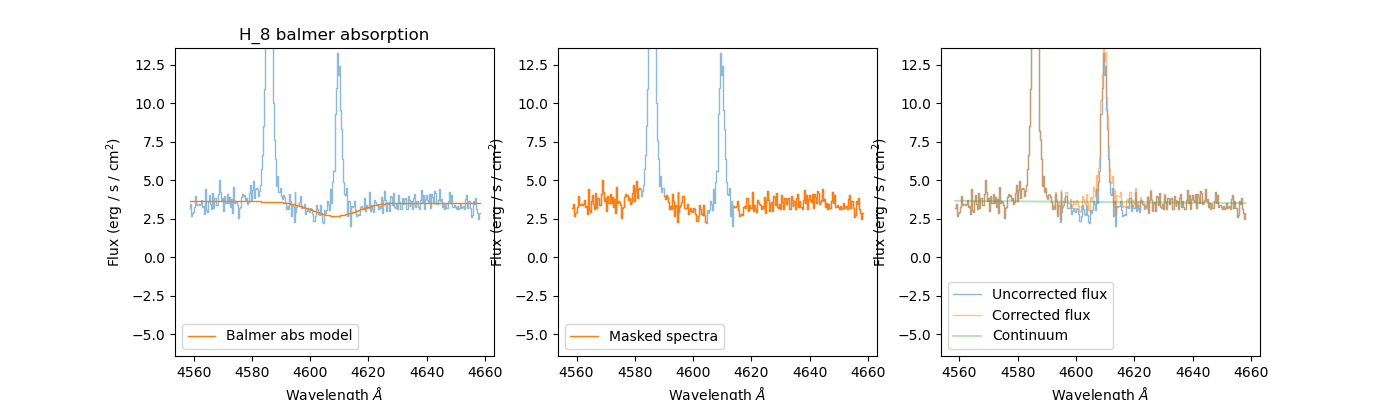

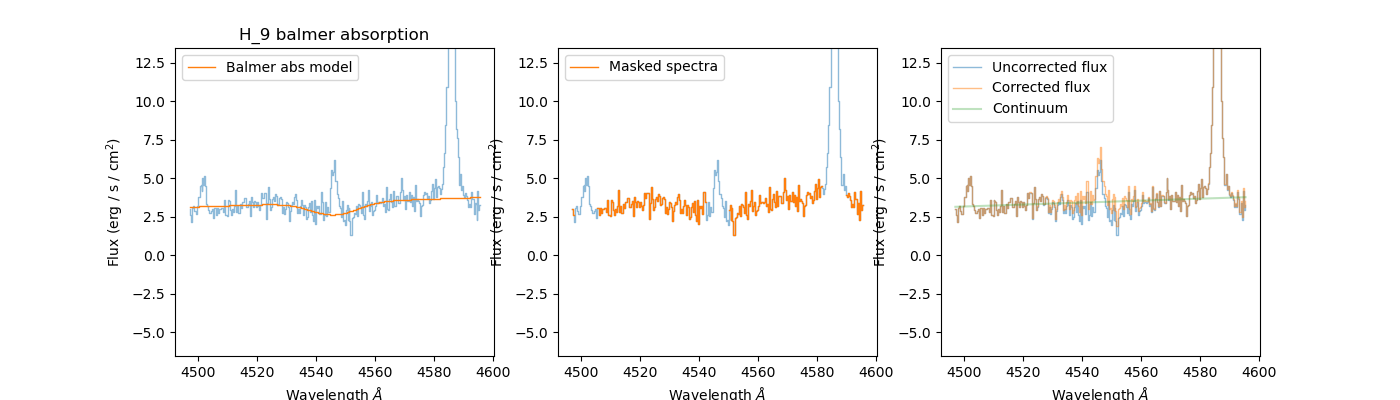

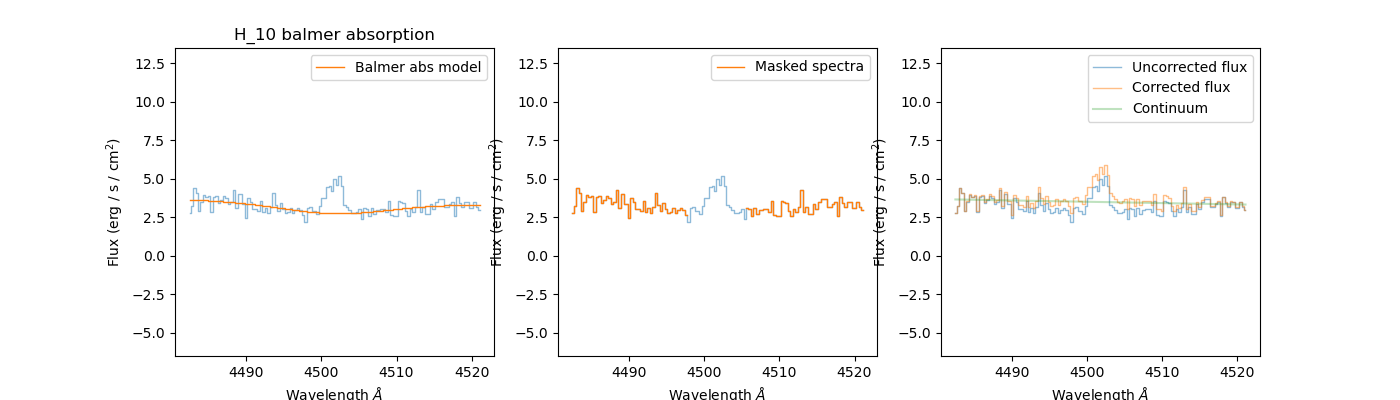

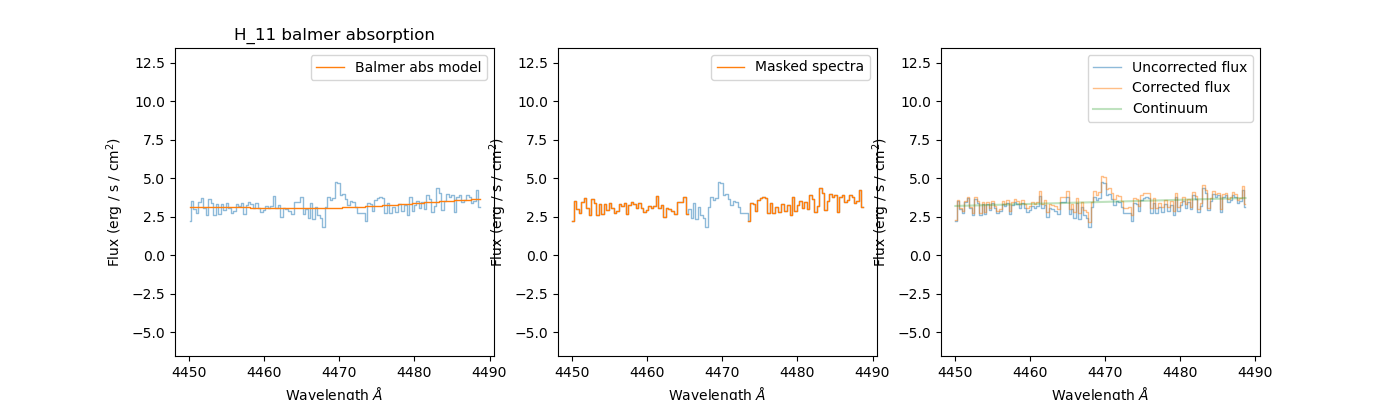

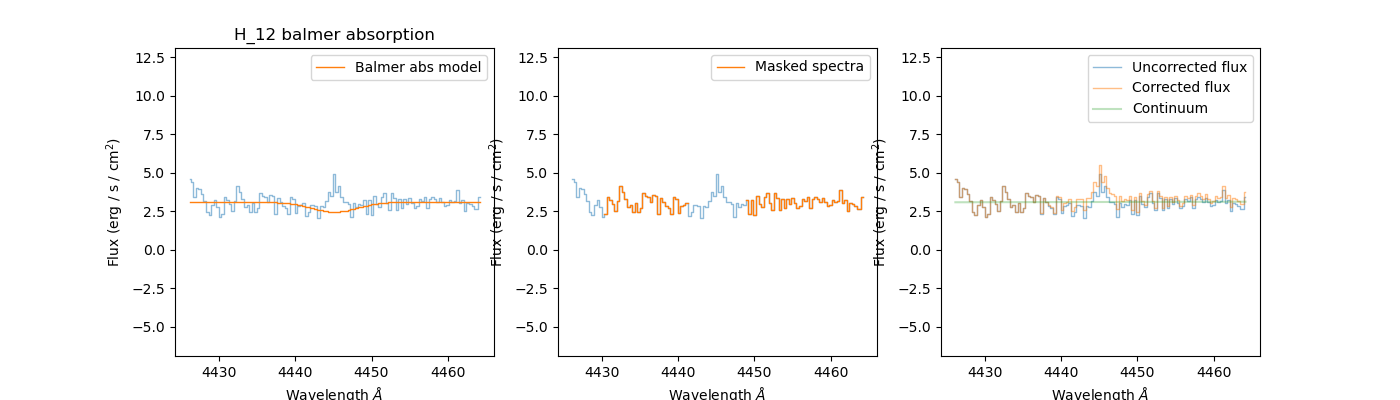

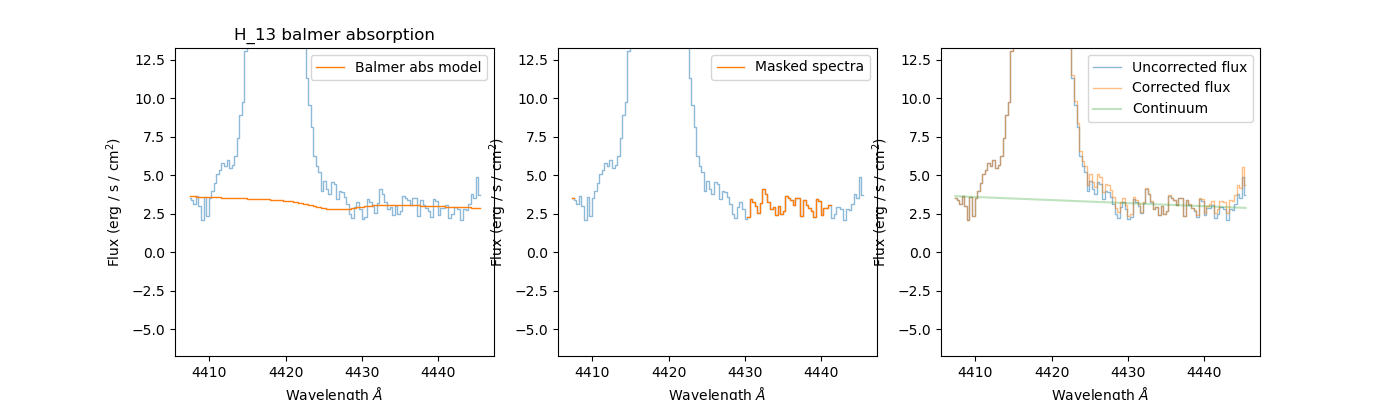

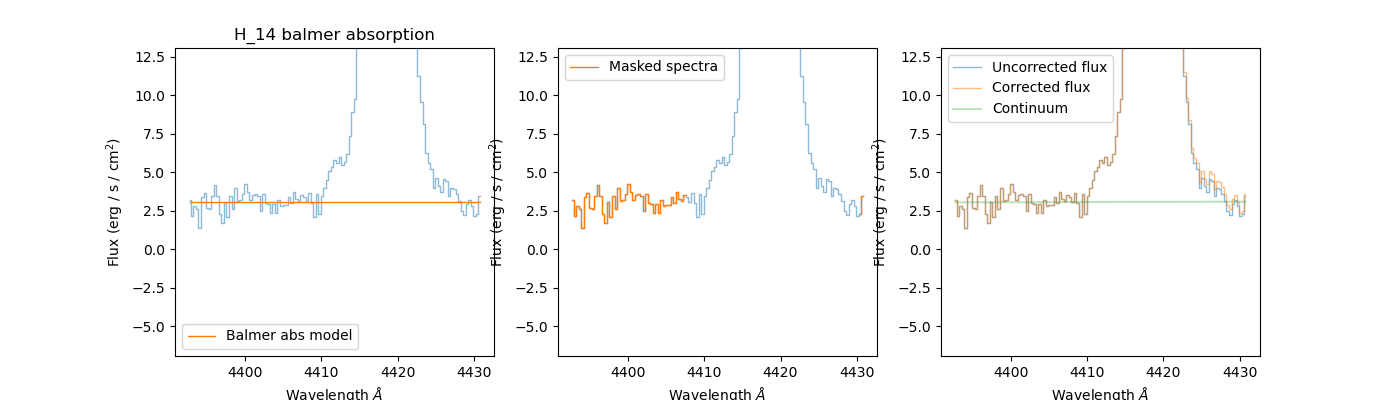

Using MW dust + Balmer abs corrected  data


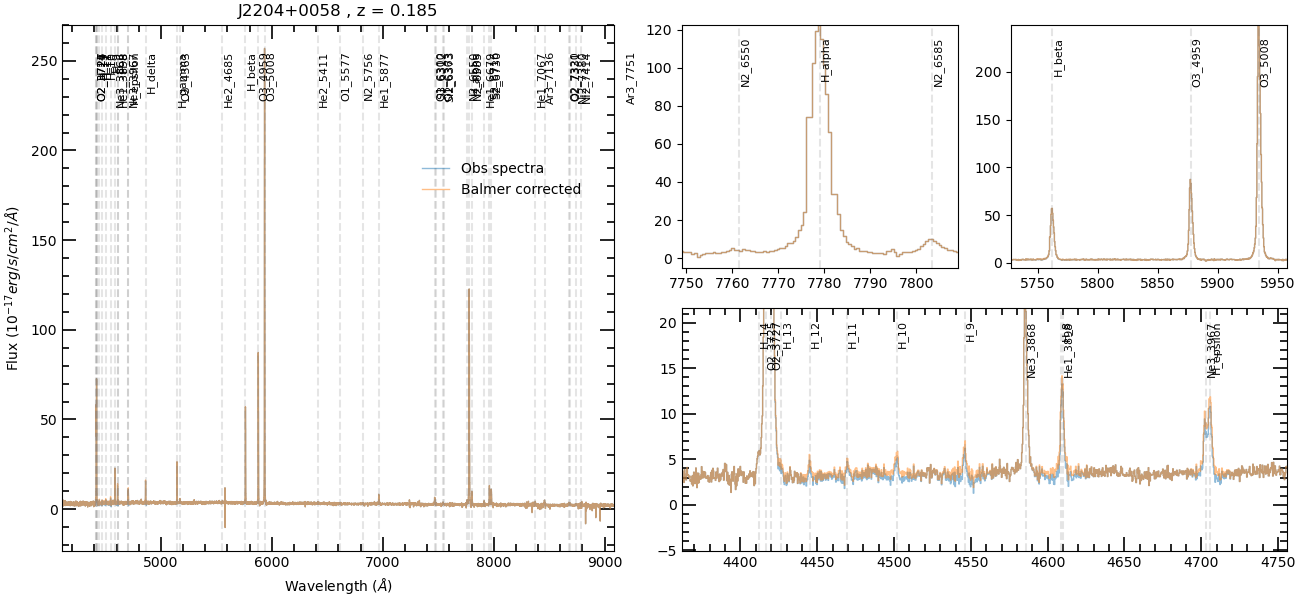

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J2204.csv
Balmer absorption correction done!


In [12]:
b = BALMER_ABS(J2204, showplot=True)

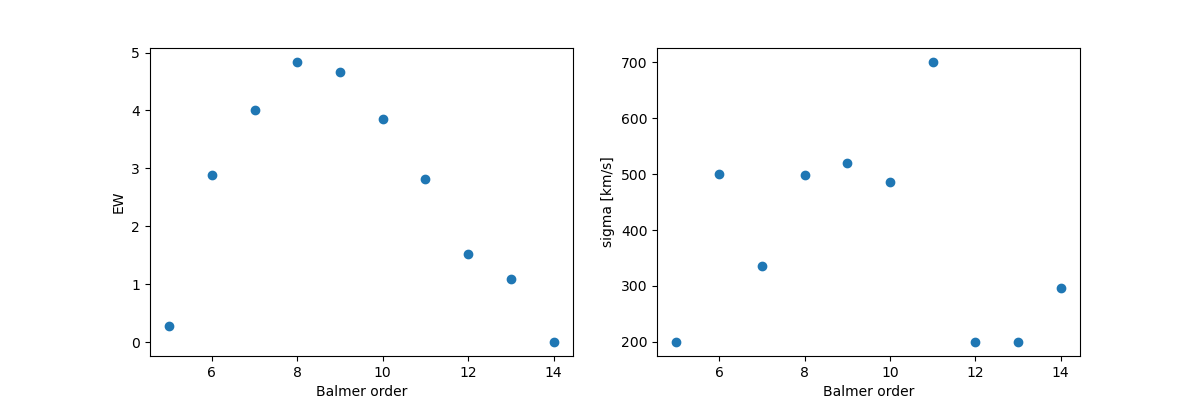

,ID,z,name,sigma,EW
0,J2204+0058,0.184996,H_beta,700.000000,-1.948966e+00
1,J2204+0058,0.184996,H_gamma,200.000000,-2.822066e-01
2,J2204+0058,0.184996,H_delta,499.137497,-2.889094e+00
3,J2204+0058,0.184996,H_epsilon,335.427423,-4.000955e+00
4,J2204+0058,0.184996,H_8,498.652006,-4.837068e+00
5,J2204+0058,0.184996,H_9,519.954943,-4.662548e+00
6,J2204+0058,0.184996,H_10,485.475088,-3.846358e+00
7,J2204+0058,0.184996,H_11,700.000787,-2.818724e+00
8,J2204+0058,0.184996,H_12,199.999776,-1.526426e+00
9,J2204+0058,0.184996,H_13,199.999813,-1.080221e+00


In [18]:
b.EW()

Reading data for J2204
Using MW dust + Balmer abs corrected  data


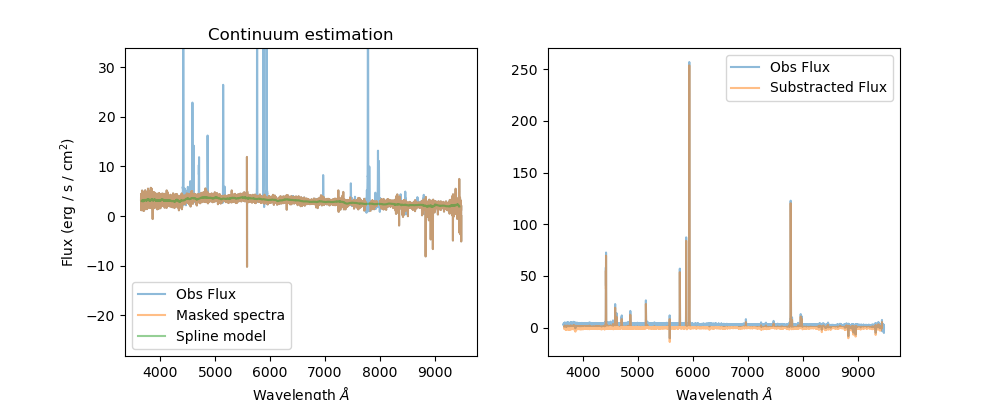

Executed cont_est in 0.2850s
Using MW dust + Balmer abs corrected  data


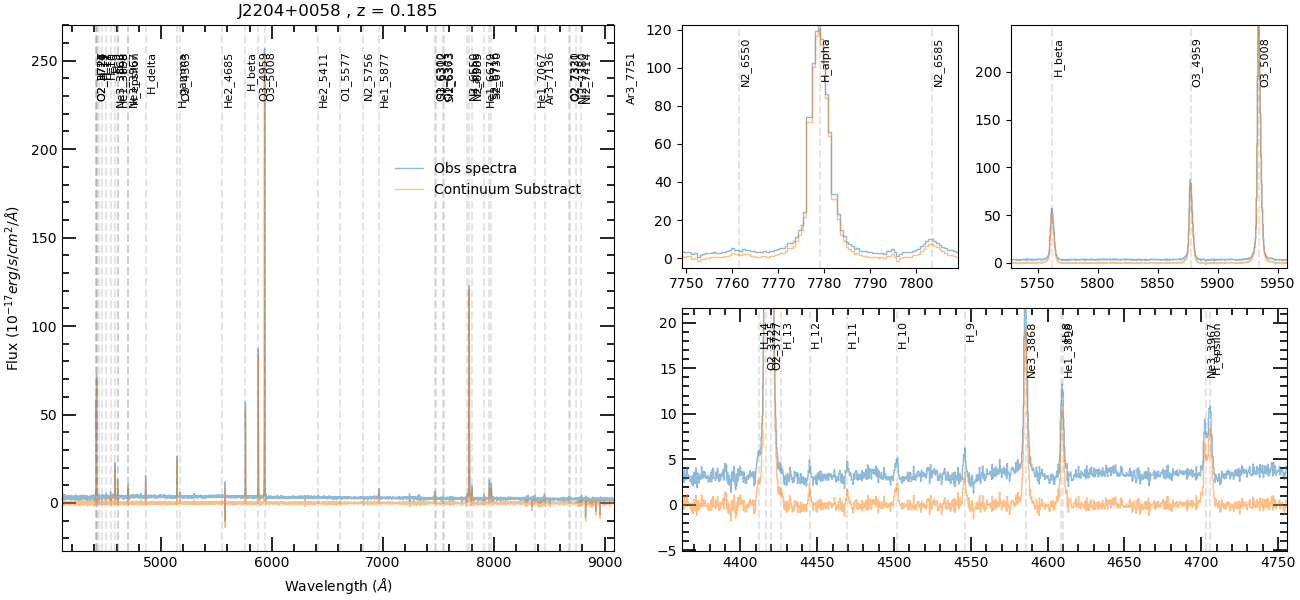

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J2204/cont_corr_J2204.csv


In [13]:
CONTINUUM_SUBSTRACT(J2204)

Reading data for J2204
Using MW dust + Balmer abs corrected and continuum substracted data


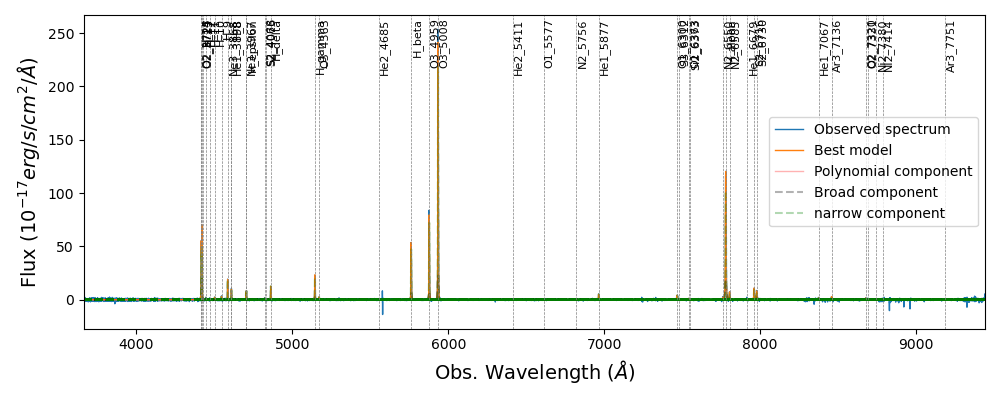

In [3]:
red = REDUC_LINES(J2204)
fit = red.fit_spectra(show_Plot=True)

In [4]:
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

12.615959811019051
9.34522872955227
9.624950044624038
8.387680497092576
12.587668520957942
12.655719337720074


In [13]:
2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0])

np.float64(10.418380871574735)

In [15]:
red.fit_MC(numMC=100)

Calculating the first initial params
Starting MC iteration
Executed fit_MC in 1114.0581s


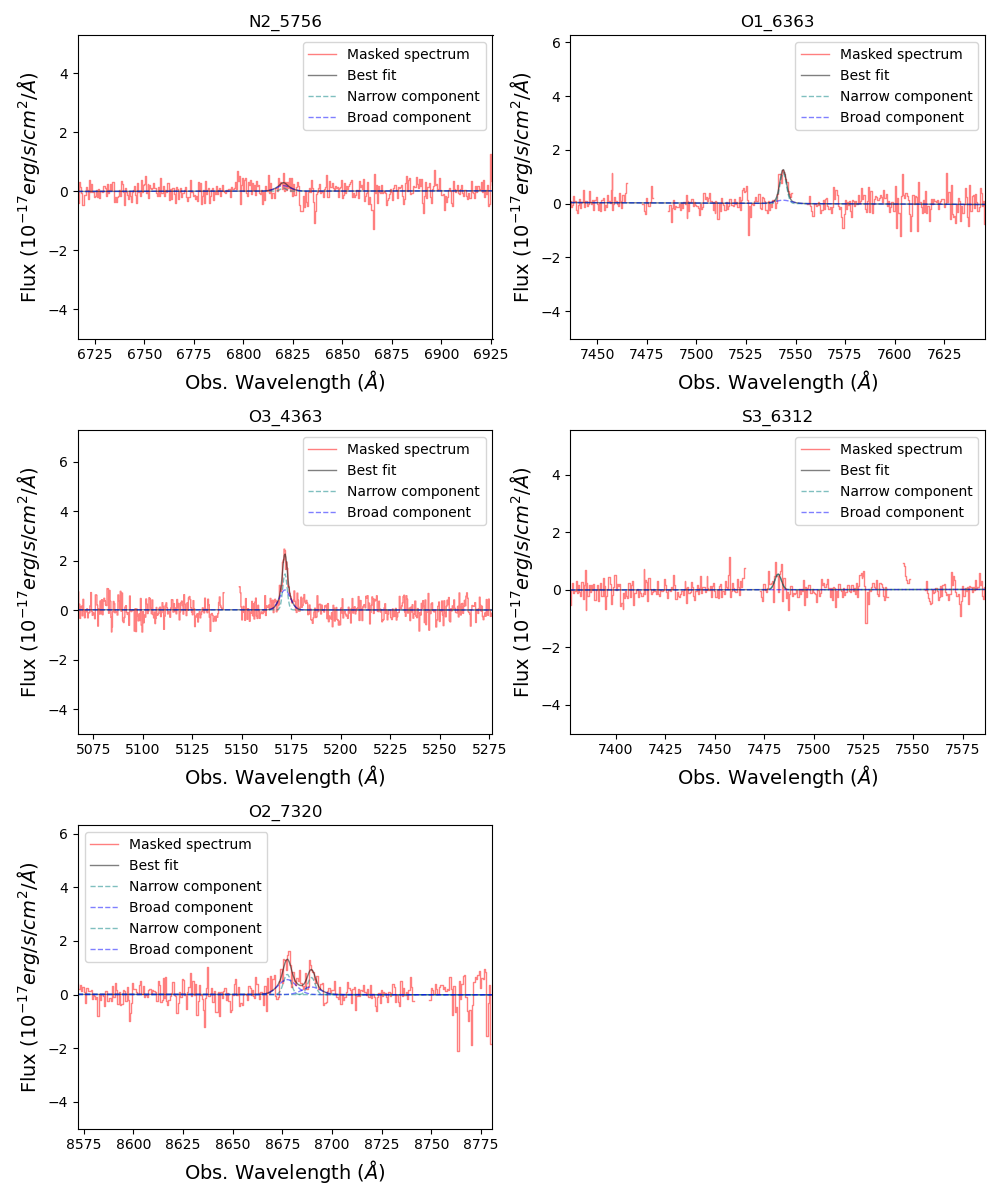

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,65.455035,157.904387,0.386377,1.676015,4.735084,1.227382,4.116042,5.485773,2.22017,3.146715e-07,3.597323,6.403555,3.053323,3.243042


In [16]:
red.fit_auroral(red.wave, red.flux, showplot=True)

In [17]:
df = red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 13.1053s
